## Make sure to do t-test for difference map versus a simple subtraction

Difference Map Creation:

Performed two-sided t-tests to identify regions with significantly positive hub scores

Visualized significant hubs on a glass brain plot

Difference Map Creation:

Created subject-level difference matrices by directly subtracting pre-processed scramble condition matrices from object condition matrices
Performed one-sample t-tests to identify regions with significantly positive hub scores
Applied FDR correction to control for multiple comparisons
Visualized significant hubs on a glass brain plot

### Write Up

##### Methods
Network Analysis
We constructed connectivity matrices for each subject during object and scrambled viewing conditions. To examine object-specific network properties, we calculated subject-level difference matrices (object minus scramble) and retained only positive differences (object > scramble) for subsequent analysis. Matrices were thresholded at mean + standard deviation of all positive connections to focus on task-relevant connectivity while removing potentially spurious weak connections.
From these thresholded matrices, we constructed weighted, undirected graphs and calculated several network metrics. Density was computed as the proportion of actual connections relative to all possible connections. The clustering coefficient represented the proportion of connected nodes across all neighboring nodes, while global efficiency was calculated as the average inverse shortest path length across the network. We also computed centrality measures including degree centrality, betweenness centrality, and eigenvector centrality for each node. A composite hub score was derived by averaging these three centrality measures for each node, and community structure was detected using the Louvain algorithm with resolution parameter γ = 1.
For hub identification, we performed one-sample t-tests on hub scores across subjects, including only regions with data from at least 5 subjects. Statistical significance was determined using FDR correction with α = 0.05.
##### Network-Level Organization of Object Processing
Graph theoretical analysis revealed a network architecture during object processing that balances integration and specialization. The object-selective network demonstrated moderate modularity (Q = 0.216 ± 0.055), indicating some community structure without strong segregation into distinct, independent modules.
The network exhibited relatively high global efficiency (E_glob = 0.537 ± 0.034), facilitating efficient information transfer across distributed regions. This was accompanied by low clustering (C = 0.086 ± 0.025) and a consistent network density (0.143 ± 0.031). This combination of properties suggests a network organization prioritizing direct, long-range connections over local clustering.
FDR-corrected hub analysis identified 44 significant hub regions within the object processing network. The most prominent hubs were located primarily in visual cortical areas, with the top four hubs being ROI 8 (7Networks_LH_Vis_9, hub score = 0.149), ROI 107 (7Networks_RH_Vis_8, hub score = 0.134), ROI 4 (7Networks_LH_Vis_5, hub score = 0.095), and ROI 105 (7Networks_RH_Vis_6, hub score = 0.075). These visual network hubs maintained extensive connections with both other visual regions and higher-order association areas.
The most connected hub (ROI 8) demonstrated significant connections with 30 regions distributed across multiple functional networks, including visual areas, dorsal attention regions, and default mode network nodes. Notably, this hub also showed significant connectivity with the functionally defined pIPS region (t = 3.979, p = 0.013), suggesting its role in integrating dorsal and ventral visual information. This prominent integration role of visual network hubs aligns with our connectivity fingerprint findings showing substantial overlap (Dice coefficient = 0.694) between dorsal and ventral pathways.
The hub distribution revealed a bilateral organization with slightly stronger representation in the left hemisphere, consistent with the left-hemisphere bias observed in our connectivity fingerprint analysis. Beyond visual areas, significant hubs were also identified in regions associated with attention (ROIs 30 and 135), default mode network (ROIs 79 and 99), and conflict monitoring (ROI 178), suggesting a distributed network supporting object recognition that extends beyond classical visual processing regions.
Collectively, these network properties support an integrated processing model in which dorsal and ventral regions maintain functional specialization while operating within a shared network framework during object recognition.


Found 18 object connectivity matrices
Found 18 scramble connectivity matrices
Created difference matrices for 18 subjects


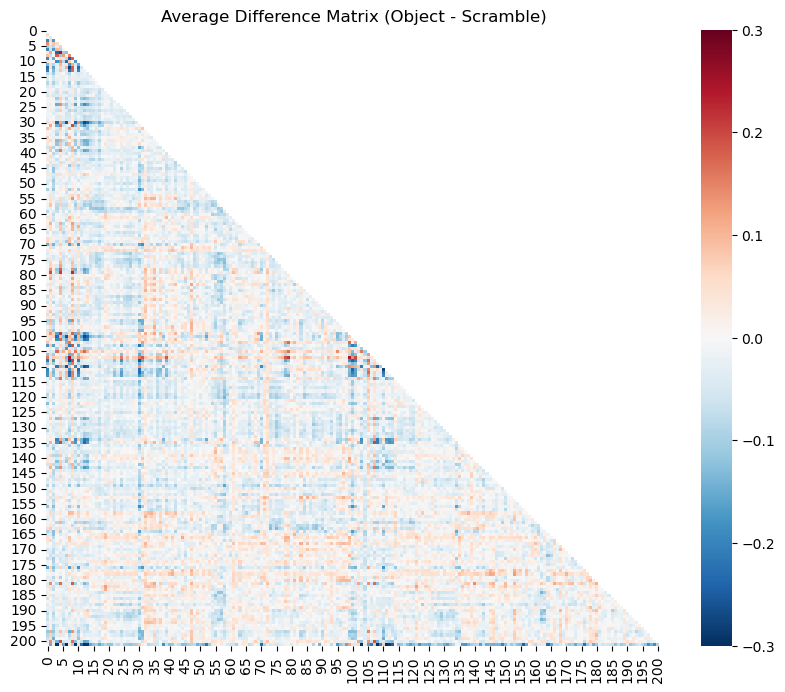

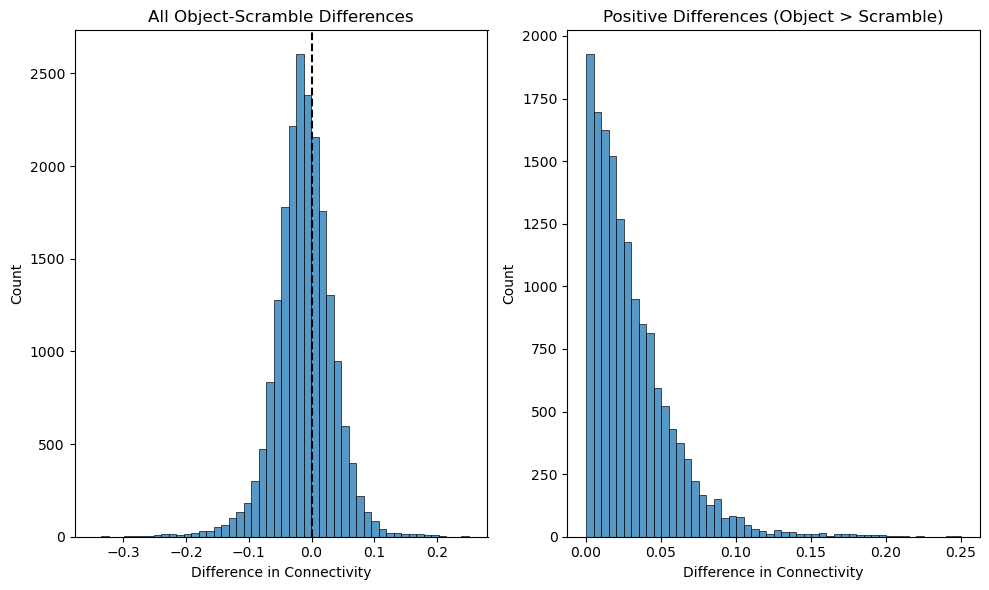


Network Metrics:
Average Density: 0.143 ± 0.031
Average Global Efficiency: 0.537 ± 0.034
Average Clustering Coefficient: 0.086 ± 0.025


<Figure size 1500x500 with 0 Axes>

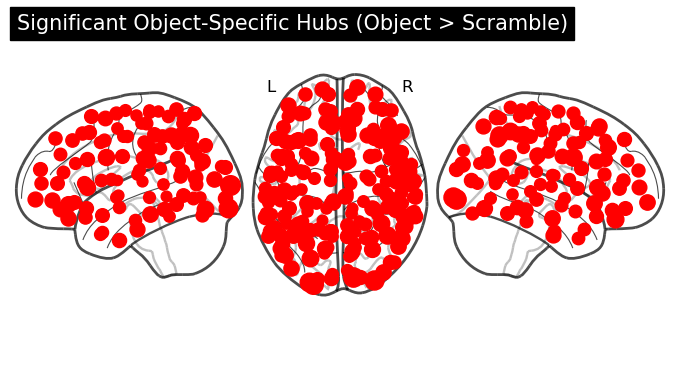


Top Object-Specific Hubs (Object > Scramble):
ROI 8: 7Networks_LH_Vis_9
  Mean Hub Score: 0.148
  T-statistic: 6.020
  P-value: 0.000014

ROI 105: 7Networks_RH_Vis_6
  Mean Hub Score: 0.143
  T-statistic: 5.402
  P-value: 0.000048

ROI 107: 7Networks_RH_Vis_8
  Mean Hub Score: 0.140
  T-statistic: 7.947
  P-value: 0.000000

ROI 4: 7Networks_LH_Vis_5
  Mean Hub Score: 0.133
  T-statistic: 6.083
  P-value: 0.000012

ROI 178: 7Networks_RH_Cont_Cing_2
  Mean Hub Score: 0.116
  T-statistic: 4.666
  P-value: 0.000221

ROI 166: 7Networks_RH_Cont_Par_3
  Mean Hub Score: 0.113
  T-statistic: 5.767
  P-value: 0.000023

ROI 158: 7Networks_RH_Limbic_OFC_1
  Mean Hub Score: 0.108
  T-statistic: 3.339
  P-value: 0.003889

ROI 1: 7Networks_LH_Vis_2
  Mean Hub Score: 0.105
  T-statistic: 5.685
  P-value: 0.000027

ROI 140: 7Networks_RH_DorsAttn_Post_7
  Mean Hub Score: 0.104
  T-statistic: 5.809
  P-value: 0.000021

ROI 72: 7Networks_LH_Cont_Cing_2
  Mean Hub Score: 0.099
  T-statistic: 4.620
  P-val

In [2]:
# Network Theory without Correction [object>scramble]
import numpy as np
import matplotlib.pyplot as plt
import community.community_louvain as community
import seaborn as sns
import pandas as pd
import glob
import os
import networkx as nx
import nibabel as nib
from nilearn import datasets, plotting
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Set up paths
curr_dir = '/user_data/csimmon2/git_repos/ptoc'
results_dir = f'{curr_dir}/results'
merged_atlas_path = f'{results_dir}/schaefer_wang_merged.nii.gz'
merged_labels_path = f'{results_dir}/merged_atlas_labels.npy'

# Load merged atlas labels
def load_merged_atlas():
    """Load the merged Schaefer+Wang atlas"""
    if os.path.exists(merged_atlas_path) and os.path.exists(merged_labels_path):
        atlas_img = nib.load(merged_atlas_path)
        labels = np.load(merged_labels_path, allow_pickle=True)
        return atlas_img, labels
    else:
        print("Merged atlas files not found. Using standard Schaefer atlas.")
        atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200)
        return nib.load(atlas.maps), atlas.labels

# Load subject matrices
def load_subject_matrices(results_dir, condition):
    """Load connectivity matrices using merged atlas"""
    matrix_dir = f'{results_dir}/connectivity_merged_{condition.lower()}'
    matrix_files = glob.glob(f'{matrix_dir}/*.npy')
    
    if not matrix_files:
        raise FileNotFoundError(f"No {condition} connectivity matrices found in {matrix_dir}")
    
    print(f"Found {len(matrix_files)} {condition} connectivity matrices")
    subjects = [os.path.basename(f).split('_')[0] for f in matrix_files]
    matrices = {sub: np.load(file) for sub, file in zip(subjects, matrix_files)}
    
    return matrices

# Create subject-level difference matrices
def create_difference_matrices(object_matrices, scramble_matrices):
    """Create difference matrices (object - scramble) for each subject"""
    diff_matrices = {}
    
    # Find subjects with data in both conditions
    common_subjects = set(object_matrices.keys()) & set(scramble_matrices.keys())
    
    for sub in common_subjects:
        diff_matrices[sub] = object_matrices[sub] - scramble_matrices[sub]
    
    print(f"Created difference matrices for {len(diff_matrices)} subjects")
    return diff_matrices

# Compute network metrics for subject-level matrices
# ===== NETWORK ANALYSIS CELL (UPDATED WITH GLOBAL EFFICIENCY) =====
import numpy as np
import networkx as nx
import community.community_louvain as community
from nilearn import plotting

# Define the key updated functions
def compute_graph_metrics(matrices):
    """Updated version using global efficiency instead of path length"""
    results = {}
    
    for sub, matrix in matrices.items():
        try:
            # Keep only positive differences (object > scramble)
            pos_matrix = matrix.copy()
            pos_matrix[pos_matrix < 0] = 0
            
            # Threshold at mean + std (unchanged from your original)
            threshold = np.mean(pos_matrix) + np.std(pos_matrix)
            matrix_thresh = pos_matrix.copy()
            matrix_thresh[matrix_thresh < threshold] = 0
            
            # Create graph (unchanged)
            G = nx.from_numpy_array(matrix_thresh)
            G.remove_edges_from(nx.selfloop_edges(G))
            
            if G.number_of_edges() == 0:
                print(f"Skipping {sub}: no edges after thresholding")
                continue
                
            # Add distance attribute (unchanged)
            for u, v, d in G.edges(data=True):
                d['distance'] = 1 / (abs(d['weight']) + 1e-6)
            
            # ===== THE KEY CHANGE =====
            # Replace avg_path_length with global_efficiency
            if nx.__version__ >= '2.6':
                global_eff = nx.global_efficiency(G)
            else:
                # Fallback for older NetworkX versions
                n = len(G)
                if n < 2:
                    global_eff = 0
                else:
                    total = sum(sum(1 / d for d in nx.shortest_path_length(G, source=node).values() if d > 0) 
                              for node in G) 
                    global_eff = total / (n * (n - 1))
            
            metrics = {
                'density': nx.density(G),
                'clustering': nx.average_clustering(G, weight='weight'),
                'global_efficiency': global_eff,  # New metric
                
                # Rest unchanged
                'degree': nx.degree_centrality(G),
                'betweenness': nx.betweenness_centrality(G, weight='distance'),
                'eigenvector': nx.eigenvector_centrality_numpy(G),
                'communities': community.best_partition(G, weight='weight'),
            }
            
            # Hub score (unchanged)
            metrics['hub_score'] = {
                node: (metrics['degree'][node] + 
                       metrics['betweenness'][node] + 
                       metrics['eigenvector'][node]) / 3
                for node in G.nodes()
            }
            
            results[sub] = metrics
            
        except Exception as e:
            print(f"Error processing {sub}: {str(e)}")
    
    return results

# Statistical testing across subjects
def test_hub_significance(metrics_dict, atlas_labels, alpha=0.05):
    """Test which ROIs show significant hub scores"""
    # Extract hub scores for all subjects
    hub_scores = {}
    n_rois = len(atlas_labels)
    
    for roi in range(n_rois):
        hub_scores[roi] = []
    
    for sub, metrics in metrics_dict.items():
        for roi, score in metrics['hub_score'].items():
            hub_scores[roi].append(score)
    
    # One-sample t-test against zero
    significant_hubs = {}
    for roi, scores in hub_scores.items():
        if len(scores) >= 5:  # Require at least 5 subjects
            t_stat, p_val = stats.ttest_1samp(scores, 0)
            if p_val < alpha and t_stat > 0:  # Only positive hubs
                significant_hubs[roi] = {
                    'p_value': p_val,
                    't_statistic': t_stat,
                    'mean_score': np.mean(scores),
                    'name': atlas_labels[roi] if roi < len(atlas_labels) else f"ROI_{roi}"
                }
    
    return significant_hubs

# Visualize hub regions
def visualize_hubs(significant_hubs, atlas_img, atlas_labels):
    """Visualize significant hub regions on glass brain"""
    # Get coordinates
    coords = plotting.find_parcellation_cut_coords(atlas_img)
    
    # Get hub indices and scores
    hub_indices = list(significant_hubs.keys())
    hub_scores = [hub['mean_score'] for hub in significant_hubs.values()]
    
    # Create scaled sizes based on hub scores
    min_size = 50
    max_size = 200
    sizes = [(score - min(hub_scores)) / (max(hub_scores) - min(hub_scores)) * 
            (max_size - min_size) + min_size for score in hub_scores]
    
    # Plot on glass brain
    plt.figure(figsize=(15, 5))
    display = plotting.plot_glass_brain(None, display_mode='lzr',
                                      title='Significant Object-Specific Hubs (Object > Scramble)')
    
    for idx, roi in enumerate(hub_indices):
        if roi < len(coords):
            display.add_markers([coords[roi]], marker_color='red', marker_size=sizes[idx])
    
    plt.show()
    
    # Print hub details
    print("\nTop Object-Specific Hubs (Object > Scramble):")
    print("=========================================")
    for roi, hub in sorted(significant_hubs.items(), key=lambda x: x[1]['mean_score'], reverse=True)[:10]:
        print(f"ROI {roi}: {hub['name']}")
        print(f"  Mean Hub Score: {hub['mean_score']:.3f}")
        print(f"  T-statistic: {hub['t_statistic']:.3f}")
        print(f"  P-value: {hub['p_value']:.6f}")
        print()

# Run full analysis
def run_full_analysis():
    """Run complete network analysis on object > scramble"""
    # Load atlas
    atlas_img, atlas_labels = load_merged_atlas()
    
    # Load matrices
    object_matrices = load_subject_matrices(results_dir, 'object')
    scramble_matrices = load_subject_matrices(results_dir, 'scramble')
    
    # Create difference matrices
    diff_matrices = create_difference_matrices(object_matrices, scramble_matrices)
    
    # Calculate average difference matrix
    avg_diff = np.mean([m for m in diff_matrices.values()], axis=0)
    
    # Visualize average difference matrix
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(avg_diff, dtype=bool))
    sns.heatmap(avg_diff, 
                mask=mask,
                cmap='RdBu_r',
                center=0,
                square=True,
                vmin=-0.3,
                vmax=0.3)
    plt.title('Average Difference Matrix (Object - Scramble)')
    plt.show()
    
    # Create positive difference matrix (object > scramble)
    pos_avg_diff = avg_diff.copy()
    pos_avg_diff[pos_avg_diff < 0] = 0
    
    # Histogram of connectivity differences
    plt.figure(figsize=(10, 6))
    plt.subplot(121)
    sns.histplot(avg_diff[~mask], bins=50)
    plt.axvline(x=0, color='k', linestyle='--')
    plt.title('All Object-Scramble Differences')
    plt.xlabel('Difference in Connectivity')
    
    plt.subplot(122)
    sns.histplot(pos_avg_diff[pos_avg_diff > 0], bins=50)
    plt.title('Positive Differences (Object > Scramble)')
    plt.xlabel('Difference in Connectivity')
    plt.tight_layout()
    plt.show()
    
    # Compute network metrics on subject-level difference matrices
    diff_metrics = compute_graph_metrics(diff_matrices)
    
    # Calculate and display average network metrics
    densities = [m['density'] for m in diff_metrics.values() if 'density' in m]
    global_efficiencies = [m['global_efficiency'] for m in diff_metrics.values() 
                        if 'global_efficiency' in m]
    clusterings = [m['clustering'] for m in diff_metrics.values() if 'clustering' in m]

    print("\nNetwork Metrics:")
    print("=================")
    print(f"Average Density: {np.mean(densities):.3f} ± {np.std(densities):.3f}")
    print(f"Average Global Efficiency: {np.mean(global_efficiencies):.3f} ± {np.std(global_efficiencies):.3f}")
    print(f"Average Clustering Coefficient: {np.mean(clusterings):.3f} ± {np.std(clusterings):.3f}")
    
    # Find significant hubs
    significant_hubs = test_hub_significance(diff_metrics, atlas_labels)
    
    # Visualize significant hubs
    visualize_hubs(significant_hubs, atlas_img, atlas_labels)
    
    return diff_matrices, diff_metrics, significant_hubs, avg_diff

# Run the full analysis
diff_matrices, diff_metrics, significant_hubs, avg_diff = run_full_analysis()

Found 44 significant hubs after FDR correction

Top Object-Specific Hubs:
ROI 8: 7Networks_LH_Vis_9
  Hub Score: 0.149 (proportion of significant connections)
  Mean T-statistic: 3.955
  Min corrected p-value: 0.007695

ROI 107: 7Networks_RH_Vis_8
  Hub Score: 0.134 (proportion of significant connections)
  Mean T-statistic: 4.729
  Min corrected p-value: 0.000192

ROI 4: 7Networks_LH_Vis_5
  Hub Score: 0.095 (proportion of significant connections)
  Mean T-statistic: 3.966
  Min corrected p-value: 0.010395

ROI 105: 7Networks_RH_Vis_6
  Hub Score: 0.075 (proportion of significant connections)
  Mean T-statistic: 4.351
  Min corrected p-value: 0.007236

ROI 99: 7Networks_LH_Default_PHC_1
  Hub Score: 0.050 (proportion of significant connections)
  Mean T-statistic: 5.062
  Min corrected p-value: 0.000960

ROI 79: 7Networks_LH_Default_Par_2
  Hub Score: 0.030 (proportion of significant connections)
  Mean T-statistic: 4.460
  Min corrected p-value: 0.011400

ROI 30: 7Networks_LH_DorsAtt

<Figure size 1500x500 with 0 Axes>

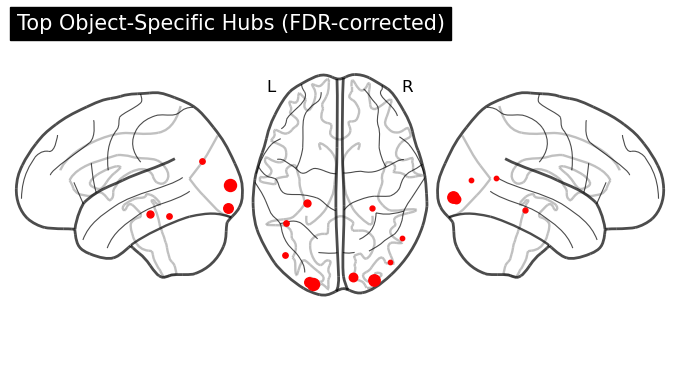

<Figure size 1500x500 with 0 Axes>

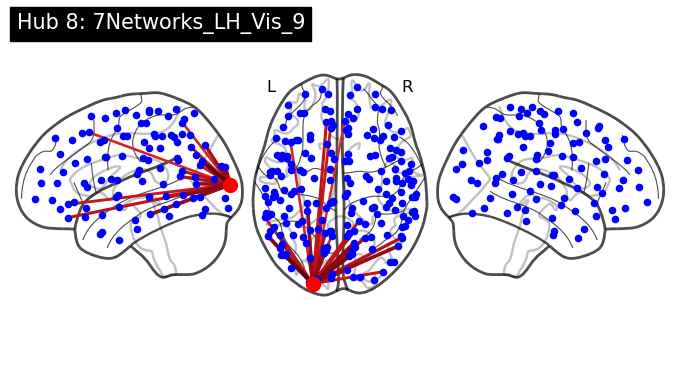


Hub 8 (7Networks_LH_Vis_9) significant connections:
- 7Networks_LH_Vis_4 (t = 4.203, p = 0.010056)
- 7Networks_LH_Vis_6 (t = 3.483, p = 0.024995)
- 7Networks_LH_Vis_10 (t = 3.501, p = 0.024995)
- 7Networks_LH_Vis_12 (t = 3.033, p = 0.047405)
- 7Networks_LH_Vis_13 (t = 3.600, p = 0.022318)
- 7Networks_LH_Vis_14 (t = 3.258, p = 0.032250)
- 7Networks_LH_DorsAttn_Post_2 (t = 5.377, p = 0.007733)
- 7Networks_LH_DorsAttn_Post_9 (t = 3.276, p = 0.032126)
- 7Networks_LH_Limbic_OFC_2 (t = 4.878, p = 0.007733)
- 7Networks_LH_Cont_Temp_1 (t = 4.158, p = 0.010246)
- 7Networks_LH_Default_Par_1 (t = 3.456, p = 0.025007)
- 7Networks_LH_Default_Par_2 (t = 4.546, p = 0.007733)
- 7Networks_LH_Default_Par_4 (t = 3.119, p = 0.042028)
- 7Networks_LH_Default_PFC_2 (t = 3.550, p = 0.023694)
- 7Networks_LH_Default_PFC_11 (t = 3.939, p = 0.013085)
- 7Networks_LH_Default_pCunPCC_1 (t = 4.420, p = 0.008411)
- 7Networks_LH_Default_PHC_1 (t = 5.044, p = 0.007733)
- 7Networks_RH_Vis_4 (t = 4.593, p = 0.007733)
- 7

In [4]:
# Apply FDR correction to hub analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import os
import networkx as nx
import community
import nibabel as nib
from nilearn import datasets, plotting
import scipy.stats as stats
from statsmodels.stats.multitest import fdrcorrection
import warnings
warnings.filterwarnings('ignore')

# Set up paths
curr_dir = '/user_data/csimmon2/git_repos/ptoc'
results_dir = f'{curr_dir}/results'
merged_atlas_path = f'{results_dir}/schaefer_wang_merged.nii.gz'
merged_labels_path = f'{results_dir}/merged_atlas_labels.npy'

# Load merged atlas labels
def load_merged_atlas():
    """Load the merged Schaefer+Wang atlas"""
    if os.path.exists(merged_atlas_path) and os.path.exists(merged_labels_path):
        atlas_img = nib.load(merged_atlas_path)
        labels = np.load(merged_labels_path, allow_pickle=True)
        return atlas_img, labels
    else:
        print("Merged atlas files not found. Using standard Schaefer atlas.")
        atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200)
        return nib.load(atlas.maps), atlas.labels

# Load subject matrices
def load_subject_matrices(results_dir, condition):
    """Load connectivity matrices using merged atlas"""
    matrix_dir = f'{results_dir}/connectivity_merged_{condition.lower()}'
    matrix_files = glob.glob(f'{matrix_dir}/*.npy')
    
    if not matrix_files:
        raise FileNotFoundError(f"No {condition} connectivity matrices found in {matrix_dir}")
    
    print(f"Found {len(matrix_files)} {condition} connectivity matrices")
    subjects = [os.path.basename(f).split('_')[0] for f in matrix_files]
    matrices = {sub: np.load(file) for sub, file in zip(subjects, matrix_files)}
    
    return matrices

# FDR correction for hub analysis
def analyze_object_hubs_with_fdr(diff_matrices, atlas_labels, alpha=0.05):
    """Identify significant hubs with FDR correction"""
    # Get average difference matrix
    avg_diff = np.mean([m for m in diff_matrices.values()], axis=0)
    
    # Keep only positive differences (object > scramble)
    pos_diff = avg_diff.copy()
    pos_diff[pos_diff < 0] = 0
    
    # Compute t-statistics for each ROI
    t_stats = []
    p_values = []
    hub_scores = []
    
    for roi in range(pos_diff.shape[0]):
        # Get connectivity values for this ROI across subjects
        roi_values = [diff[roi, :] for diff in diff_matrices.values()]
        roi_values = np.array(roi_values)
        
        # Compute t-statistic for each connection
        t_roi = []
        p_roi = []
        
        for conn in range(pos_diff.shape[1]):
            if roi != conn:  # Skip self-connections
                t, p = stats.ttest_1samp(roi_values[:, conn], 0)
                t_roi.append(t)
                p_roi.append(p)
        
        # Apply FDR correction to connections
        if len(p_roi) > 0:
            significant, corrected_p = fdrcorrection(p_roi, alpha=alpha)
            
            # Count significant positive connections
            pos_t = np.array(t_roi) > 0
            sig_pos = significant & pos_t
            hub_score = np.sum(sig_pos) / len(p_roi)
            
            t_stats.append(np.mean(np.array(t_roi)[sig_pos]) if np.any(sig_pos) else 0)
            p_values.append(np.min(np.array(corrected_p)[sig_pos]) if np.any(sig_pos) else 1.0)
            hub_scores.append(hub_score)
        else:
            t_stats.append(0)
            p_values.append(1.0)
            hub_scores.append(0)
    
    # Create results dataframe
    results = pd.DataFrame({
        'ROI': range(len(hub_scores)),
        'Hub_Score': hub_scores,
        'Mean_T': t_stats,
        'Min_P': p_values,
        'Label': [atlas_labels[i] if i < len(atlas_labels) else f"ROI_{i}" for i in range(len(hub_scores))]
    })
    
    # Filter for significant hubs
    sig_hubs = results[results['Min_P'] < alpha].sort_values('Hub_Score', ascending=False)
    
    return sig_hubs, results

# Plot network for a specific hub
def plot_hub_network(hub_roi, diff_matrices, atlas_labels, atlas_img):
    """Create a network plot for a specific hub ROI"""
    # Get average difference matrix
    avg_diff = np.mean([m for m in diff_matrices.values()], axis=0)
    
    # Get coordinates for all ROIs
    coords = plotting.find_parcellation_cut_coords(atlas_img)
    
    # Get t-statistics for connections
    roi_values = [diff[hub_roi, :] for diff in diff_matrices.values()]
    roi_values = np.array(roi_values)
    
    t_stats = []
    p_values = []
    
    for conn in range(avg_diff.shape[1]):
        if hub_roi != conn:  # Skip self-connections
            t, p = stats.ttest_1samp(roi_values[:, conn], 0)
            t_stats.append(t)
            p_values.append(p)
        else:
            t_stats.append(0)
            p_values.append(1.0)
    
    # Apply FDR correction
    significant, corrected_p = fdrcorrection(p_values, alpha=0.05)
    
    # Keep only significant positive connections
    pos_t = np.array(t_stats) > 0
    sig_pos = significant & pos_t
    
    # Create connection matrix
    conn_matrix = np.zeros((avg_diff.shape[0], avg_diff.shape[0]))
    
    sig_indices = np.where(sig_pos)[0]
    for idx in sig_indices:
        conn_matrix[hub_roi, idx] = avg_diff[hub_roi, idx]
        conn_matrix[idx, hub_roi] = avg_diff[hub_roi, idx]
    
    # Plot the network
    hub_name = atlas_labels[hub_roi] if hub_roi < len(atlas_labels) else f"ROI_{hub_roi}"
    plt.figure(figsize=(15, 5))
    
    display = plotting.plot_connectome(
        conn_matrix, coords, 
        node_color="blue",
        node_size=20,
        edge_cmap='Reds',
        display_mode='lzr',
        title=f"Hub {hub_roi}: {hub_name}"
    )
    
    # Highlight hub node
    display.add_markers([coords[hub_roi]], marker_color='red', marker_size=100)
    plt.show()
    
    # Print connection information
    print(f"\nHub {hub_roi} ({hub_name}) significant connections:")
    for idx in sig_indices:
        target_name = atlas_labels[idx] if idx < len(atlas_labels) else f"ROI_{idx}"
        print(f"- {target_name} (t = {t_stats[idx]:.3f}, p = {corrected_p[idx]:.6f})")

# Run the FDR-corrected analysis (using previously loaded diff_matrices)
atlas_img, atlas_labels = load_merged_atlas()
sig_hubs, all_hub_results = analyze_object_hubs_with_fdr(diff_matrices, atlas_labels)

# Display top hubs
print(f"Found {len(sig_hubs)} significant hubs after FDR correction")
print("\nTop Object-Specific Hubs:")
print("====================")
for _, hub in sig_hubs.head(10).iterrows():
    print(f"ROI {int(hub['ROI'])}: {hub['Label']}")
    print(f"  Hub Score: {hub['Hub_Score']:.3f} (proportion of significant connections)")
    print(f"  Mean T-statistic: {hub['Mean_T']:.3f}")
    print(f"  Min corrected p-value: {hub['Min_P']:.6f}")
    print()

# Visualize top hubs on brain
plt.figure(figsize=(15, 5))
display = plotting.plot_glass_brain(None, display_mode='lzr',
                                  title='Top Object-Specific Hubs (FDR-corrected)')

# Get coordinates
coords = plotting.find_parcellation_cut_coords(atlas_img)

# Add markers for top 10 hubs or all if fewer
top_n = min(10, len(sig_hubs))
for _, hub in sig_hubs.head(top_n).iterrows():
    roi = int(hub['ROI'])
    if roi < len(coords):
        display.add_markers([coords[roi]], marker_color='red', 
                          marker_size=hub['Hub_Score']*500)  # Size by hub score
plt.show()

# Plot network for top hub
if len(sig_hubs) > 0:
    top_hub_roi = int(sig_hubs.iloc[0]['ROI'])
    plot_hub_network(top_hub_roi, diff_matrices, atlas_labels, atlas_img)

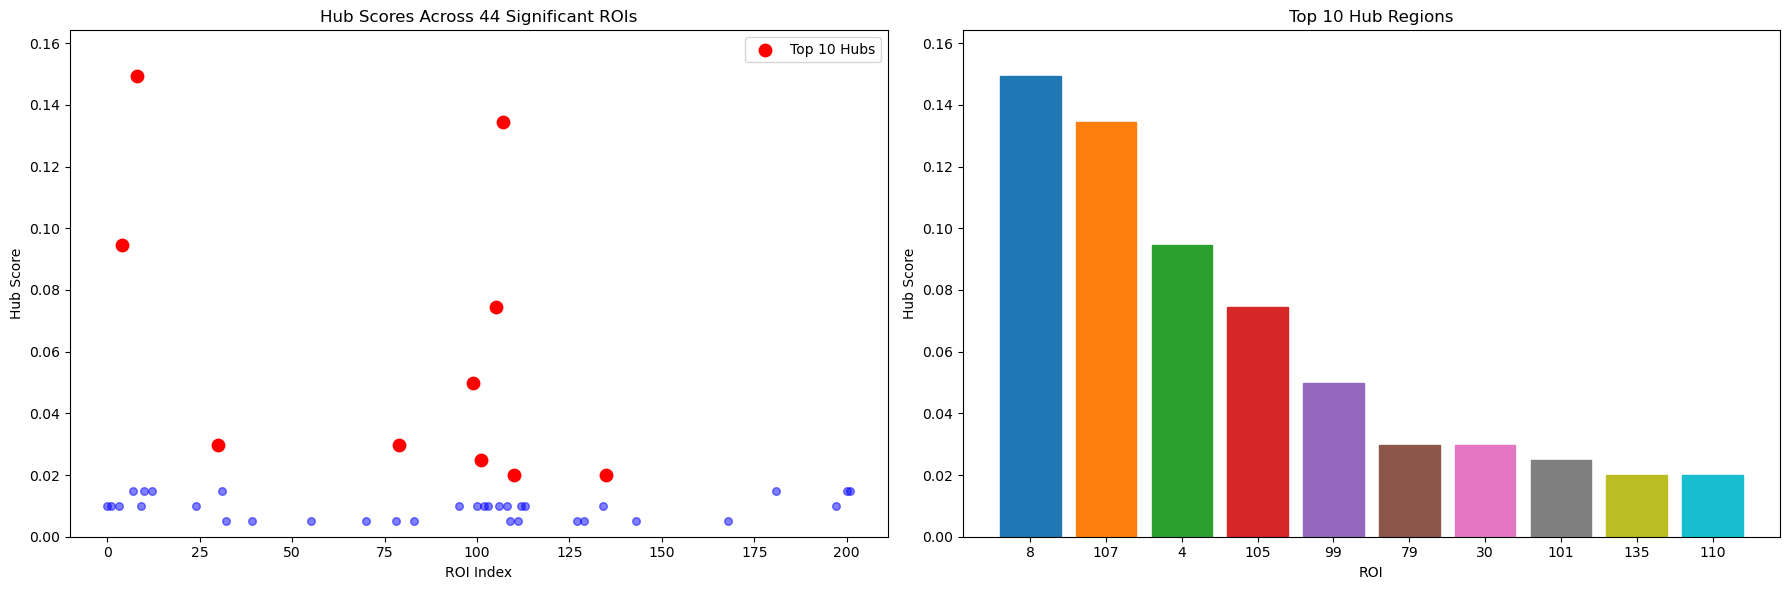

In [57]:
# Create improved hub score visualization
def visualize_hub_scores_enhanced(sig_hubs):
    """Create improved visualization of significant hub scores"""
    plt.figure(figsize=(18, 6))
    
    # Left plot: Scatter plot of all significant ROIs
    plt.subplot(121)
    all_sig_rois = sig_hubs['ROI'].values
    all_sig_scores = sig_hubs['Hub_Score'].values
    
    # Plot all significant ROIs
    plt.scatter(all_sig_rois, all_sig_scores, c='blue', alpha=0.5, s=30)
    
    # Highlight top 10 hubs
    top_hubs = sig_hubs.head(10)
    plt.scatter(top_hubs['ROI'].values, top_hubs['Hub_Score'].values, 
               c='red', s=80, label='Top 10 Hubs')
    
    # Set y-axis range to focus on the data
    max_score = sig_hubs['Hub_Score'].max()
    plt.ylim(0, max_score * 1.1)  # Add 10% margin
    
    plt.xlabel('ROI Index')
    plt.ylabel('Hub Score')
    plt.title(f'Hub Scores Across {len(sig_hubs)} Significant ROIs')
    plt.legend()
    
    # Right plot: Bar chart of top 10 hubs
    plt.subplot(122)
    top_rois = top_hubs['ROI'].values
    top_scores = top_hubs['Hub_Score'].values
    
    # Create bar chart
    bars = plt.bar(range(len(top_rois)), top_scores)
    
    # Set same y-axis range as scatter plot
    plt.ylim(0, max_score * 1.1)
    
    # Customize colors
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_rois)))
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    plt.xlabel('ROI')
    plt.ylabel('Hub Score')
    plt.title('Top 10 Hub Regions')
    plt.xticks(range(len(top_rois)), top_rois)
    
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_hub_scores_enhanced(sig_hubs)

<Figure size 1500x500 with 0 Axes>

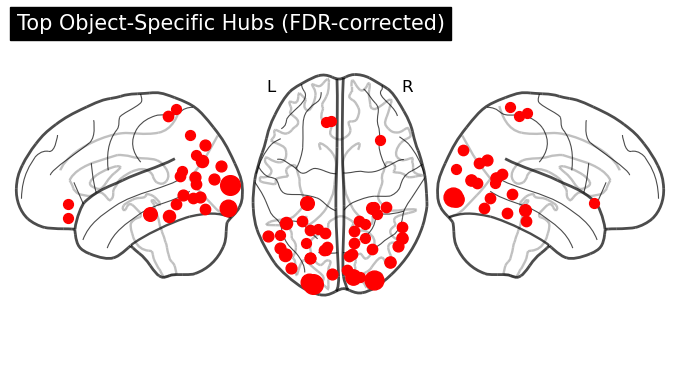

In [58]:
# Plot all significant hubs on glass brain
def visualize_all_significant_hubs(sig_hubs, atlas_img):
    """Visualize all significant hub regions on glass brain"""
    # Get coordinates
    coords = plotting.find_parcellation_cut_coords(atlas_img)
    
    # Scale marker sizes by hub score
    hub_scores = sig_hubs['Hub_Score'].values
    min_score = min(hub_scores)
    max_score = max(hub_scores)
    
    # Create scaled sizes (min 5, max 20)
    sizes = [5 + ((score - min_score) / (max_score - min_score)) * 15 
             if max_score > min_score else 10 for score in hub_scores]
    
    # Plot on glass brain
    plt.figure(figsize=(15, 5))
    display = plotting.plot_glass_brain(None, display_mode='lzr',
                                      title='Top Object-Specific Hubs (FDR-corrected)')
    
    # Add all significant hubs
    for i, roi in enumerate(sig_hubs['ROI'].values):
        if int(roi) < len(coords):
            display.add_markers([coords[int(roi)]], marker_color='red', 
                              marker_size=sizes[i]*10)
    
    plt.show()

# Run visualization with all significant hubs
visualize_all_significant_hubs(sig_hubs, atlas_img)


Network Metrics:
--------------
Clustering: 0.086 ± 0.025
Path Length: 2.005 ± 0.106
Modularity: 0.216 ± 0.055
Small-World Coefficient: 0.630 ± 0.321


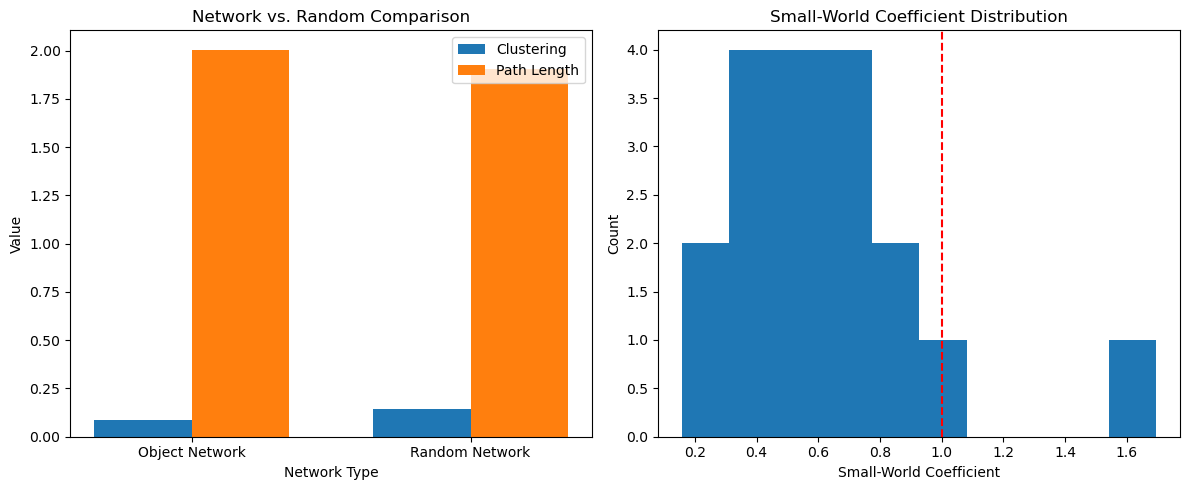

In [14]:
# 1. Network-level metrics comparison
def analyze_network_properties(diff_matrices):
    """Calculate and compare network metrics to random networks"""
    import bct
    
    # Store results
    results = {
        'clustering': [],
        'path_length': [],
        'modularity': [],
        'random_clustering': [],
        'random_path_length': [],
        'small_world': []
    }
    
    # Process each subject
    for sub, matrix in diff_matrices.items():
        try:
            # Keep only positive values (object > scramble)
            pos_matrix = matrix.copy()
            pos_matrix[pos_matrix < 0] = 0
            
            # Threshold at mean + std
            threshold = np.mean(pos_matrix) + np.std(pos_matrix)
            matrix_thresh = pos_matrix.copy()
            matrix_thresh[matrix_thresh < threshold] = 0
            
            # Skip if not enough edges
            if np.sum(matrix_thresh > 0) < 10:
                continue
                
            # Create network
            G = nx.from_numpy_array(matrix_thresh)
            G.remove_edges_from(nx.selfloop_edges(G))
            
            # Calculate metrics
            clust = nx.average_clustering(G, weight='weight')
            
            # Path length (using largest component if disconnected)
            if nx.is_connected(G):
                path_length = nx.average_shortest_path_length(G, weight='distance')
            else:
                largest_cc = max(nx.connected_components(G), key=len)
                G_cc = G.subgraph(largest_cc)
                path_length = nx.average_shortest_path_length(G_cc, weight='distance')
            
            # Modularity
            comms = community.best_partition(G, weight='weight')
            mod_score = community.modularity(comms, G, weight='weight')
            
            # Generate equivalent random network
            n_nodes = G.number_of_nodes()
            n_edges = G.number_of_edges()
            G_rand = nx.gnm_random_graph(n_nodes, n_edges)
            
            # Random network metrics
            rand_clust = nx.average_clustering(G_rand)
            
            if nx.is_connected(G_rand):
                rand_path = nx.average_shortest_path_length(G_rand)
            else:
                largest_cc = max(nx.connected_components(G_rand), key=len)
                G_cc = G_rand.subgraph(largest_cc)
                rand_path = nx.average_shortest_path_length(G_cc)
            
            # Calculate small-worldness
            small_world = (clust/rand_clust) / (path_length/rand_path)
            
            # Store results
            results['clustering'].append(clust)
            results['path_length'].append(path_length)
            results['modularity'].append(mod_score)
            results['random_clustering'].append(rand_clust)
            results['random_path_length'].append(rand_path)
            results['small_world'].append(small_world)
            
        except Exception as e:
            print(f"Error processing {sub}: {e}")
    
    # Summarize results
    print("\nNetwork Metrics:")
    print("--------------")
    print(f"Clustering: {np.mean(results['clustering']):.3f} ± {np.std(results['clustering']):.3f}")
    print(f"Path Length: {np.mean(results['path_length']):.3f} ± {np.std(results['path_length']):.3f}")
    print(f"Modularity: {np.mean(results['modularity']):.3f} ± {np.std(results['modularity']):.3f}")
    print(f"Small-World Coefficient: {np.mean(results['small_world']):.3f} ± {np.std(results['small_world']):.3f}")
    
    # Create plot
    plt.figure(figsize=(12, 5))
    
    # Network vs Random
    plt.subplot(121)
    x = np.arange(2)
    width = 0.35
    
    plt.bar(x - width/2, 
            [np.mean(results['clustering']), np.mean(results['random_clustering'])], 
            width, label='Clustering')
    plt.bar(x + width/2, 
            [np.mean(results['path_length']), np.mean(results['random_path_length'])], 
            width, label='Path Length')
    
    plt.xlabel('Network Type')
    plt.ylabel('Value')
    plt.title('Network vs. Random Comparison')
    plt.xticks(x, ['Object Network', 'Random Network'])
    plt.legend()
    
    # Small-World Distribution
    plt.subplot(122)
    plt.hist(results['small_world'], bins=10)
    plt.axvline(x=1, color='r', linestyle='--')
    plt.xlabel('Small-World Coefficient')
    plt.ylabel('Count')
    plt.title('Small-World Coefficient Distribution')
    
    plt.tight_layout()
    plt.show()
    
    return results

# Run network analysis
network_results = analyze_network_properties(diff_matrices)

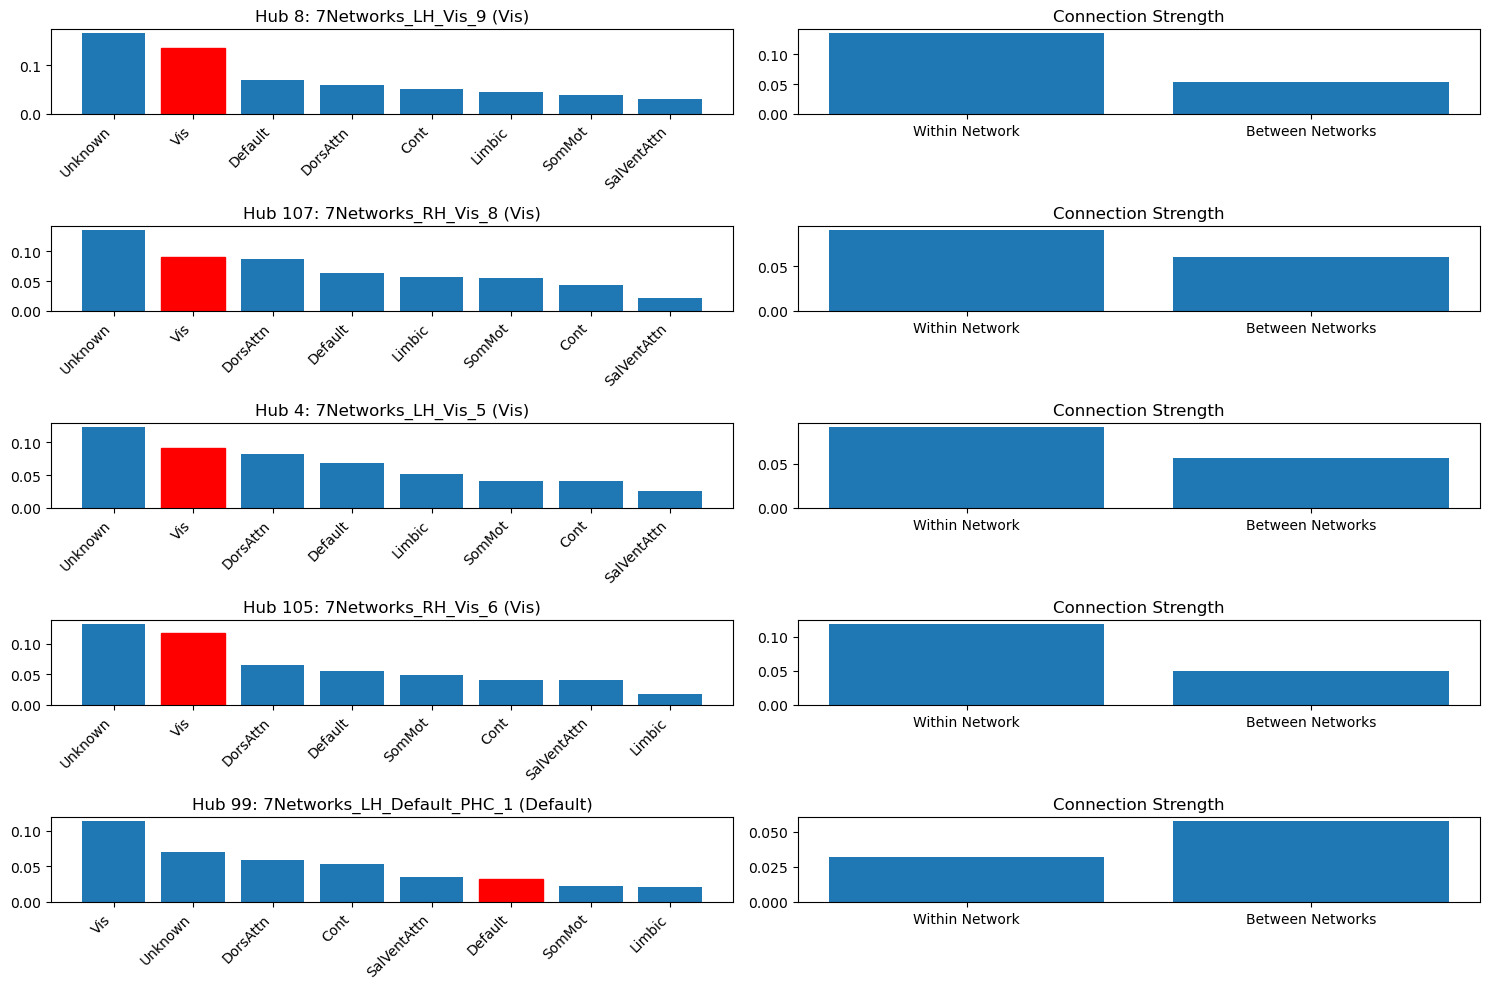


Top Hub Network Affiliations:
---------------------------
Hub 8: 7Networks_LH_Vis_9 - Network: Vis
Hub 107: 7Networks_RH_Vis_8 - Network: Vis
Hub 4: 7Networks_LH_Vis_5 - Network: Vis
Hub 105: 7Networks_RH_Vis_6 - Network: Vis
Hub 99: 7Networks_LH_Default_PHC_1 - Network: Default


In [18]:
# 2. Hub-specific connectivity analysis
def analyze_hub_connectivity(top_hubs, diff_matrices, atlas_labels):
    """Analyze connection patterns of top hub regions"""
    # Get average difference matrix
    avg_diff = np.mean([m for m in diff_matrices.values()], axis=0)
    
    # Extract network labels from atlas labels
    network_mapping = {}
    for i, label in enumerate(atlas_labels):
        if isinstance(label, bytes):
            label = label.decode('utf-8')
        
        # Extract network from label (e.g., "7Networks_LH_Vis_1" -> "Vis")
        parts = str(label).split('_')
        if len(parts) >= 3:
            network_mapping[i] = parts[2]
        else:
            network_mapping[i] = "Unknown"
    
    # Analyze top 5 hubs
    top_n = min(5, len(top_hubs))
    hub_rois = top_hubs.head(top_n)['ROI'].values.astype(int)
    
    # Create figure
    plt.figure(figsize=(15, 10))
    
    # Process each hub
    for i, hub_roi in enumerate(hub_rois):
        # Get hub's network
        hub_network = network_mapping[hub_roi]
        
        # Get all connections for this hub
        connections = avg_diff[hub_roi, :]
        
        # Separate by network
        networks = {}
        for roi, network in network_mapping.items():
            if network not in networks:
                networks[network] = []
            if roi != hub_roi:  # Exclude self-connection
                networks[network].append(connections[roi])
        
        # Calculate mean connection strength by network
        network_strengths = {net: np.mean([c for c in conns if c > 0]) 
                           for net, conns in networks.items()}
        
        # Plot
        plt.subplot(top_n, 2, i*2+1)
        nets = list(network_strengths.keys())
        strengths = [network_strengths[net] if net in network_strengths else 0 for net in nets]
        
        # Sort by strength
        sorted_idx = np.argsort(strengths)[::-1]
        sorted_nets = [nets[j] for j in sorted_idx]
        sorted_strengths = [strengths[j] for j in sorted_idx]
        
        # Plot as bar chart
        bars = plt.bar(range(len(sorted_nets)), sorted_strengths)
        plt.xticks(range(len(sorted_nets)), sorted_nets, rotation=45, ha='right')
        plt.title(f"Hub {hub_roi}: {atlas_labels[hub_roi]} ({hub_network})")
        plt.tight_layout()
        
        # Color the hub's own network differently
        for j, net in enumerate(sorted_nets):
            if net == hub_network:
                bars[j].set_color('red')
        
        # Within vs. between network connectivity
        plt.subplot(top_n, 2, i*2+2)
        
        # Categorize connections
        within = [c for roi, c in enumerate(connections) 
                 if c > 0 and network_mapping.get(roi) == hub_network]
        between = [c for roi, c in enumerate(connections) 
                 if c > 0 and network_mapping.get(roi) != hub_network]
        
        within_mean = np.mean(within) if within else 0
        between_mean = np.mean(between) if between else 0
        
        plt.bar(['Within Network', 'Between Networks'], [within_mean, between_mean])
        plt.title('Connection Strength')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nTop Hub Network Affiliations:")
    print("---------------------------")
    for hub_roi in hub_rois:
        print(f"Hub {hub_roi}: {atlas_labels[hub_roi]} - Network: {network_mapping[hub_roi]}")

# Run hub connectivity analysis
analyze_hub_connectivity(sig_hubs, diff_matrices, atlas_labels)

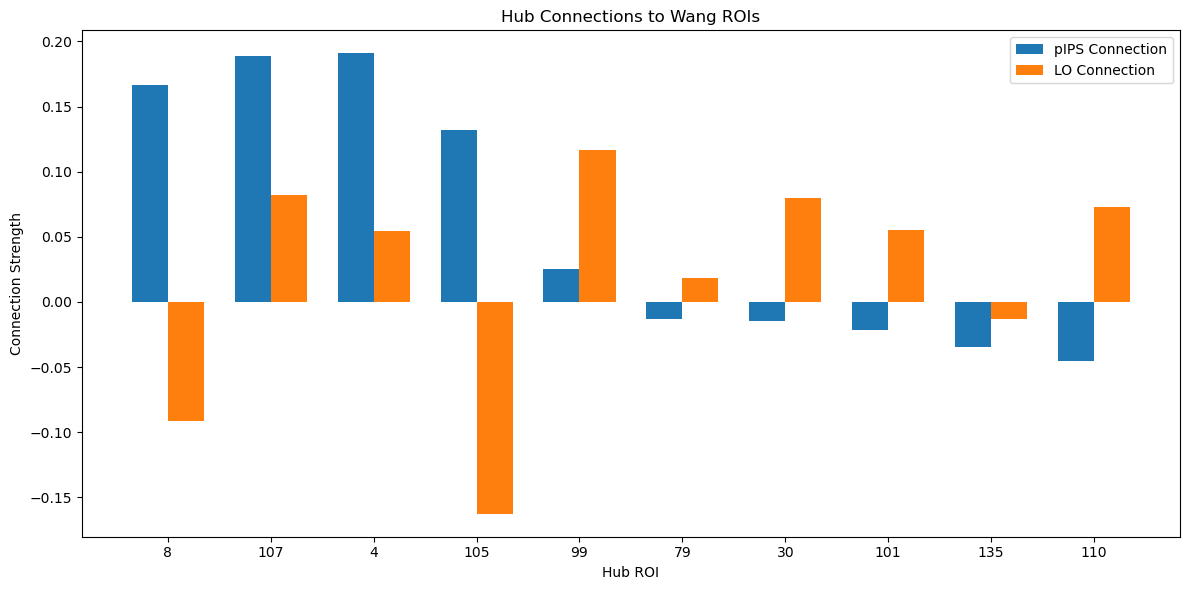

<Figure size 1000x800 with 0 Axes>

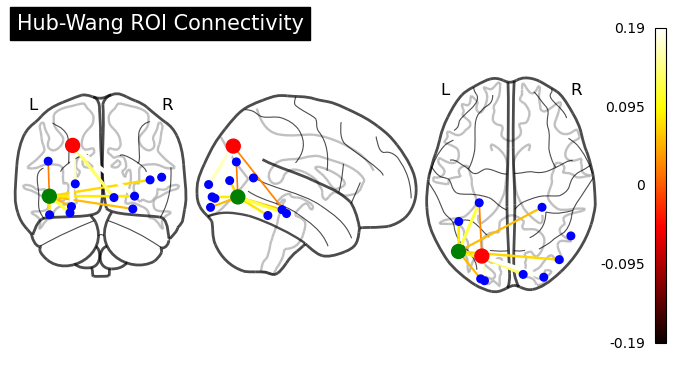


Wang ROI Connections:
------------------
pIPS (ROI 200):
  Hub 8: 7Networks_LH_Vis_9 (strength: 0.166)
  Hub 107: 7Networks_RH_Vis_8 (strength: 0.188)
  Hub 4: 7Networks_LH_Vis_5 (strength: 0.191)
  Hub 105: 7Networks_RH_Vis_6 (strength: 0.132)
  Hub 99: 7Networks_LH_Default_PHC_1 (strength: 0.025)

LO (ROI 201):
  Hub 107: 7Networks_RH_Vis_8 (strength: 0.082)
  Hub 4: 7Networks_LH_Vis_5 (strength: 0.055)
  Hub 99: 7Networks_LH_Default_PHC_1 (strength: 0.117)
  Hub 79: 7Networks_LH_Default_Par_2 (strength: 0.019)
  Hub 30: 7Networks_LH_DorsAttn_Post_1 (strength: 0.080)
  Hub 101: 7Networks_RH_Vis_2 (strength: 0.056)
  Hub 110: 7Networks_RH_Vis_11 (strength: 0.073)


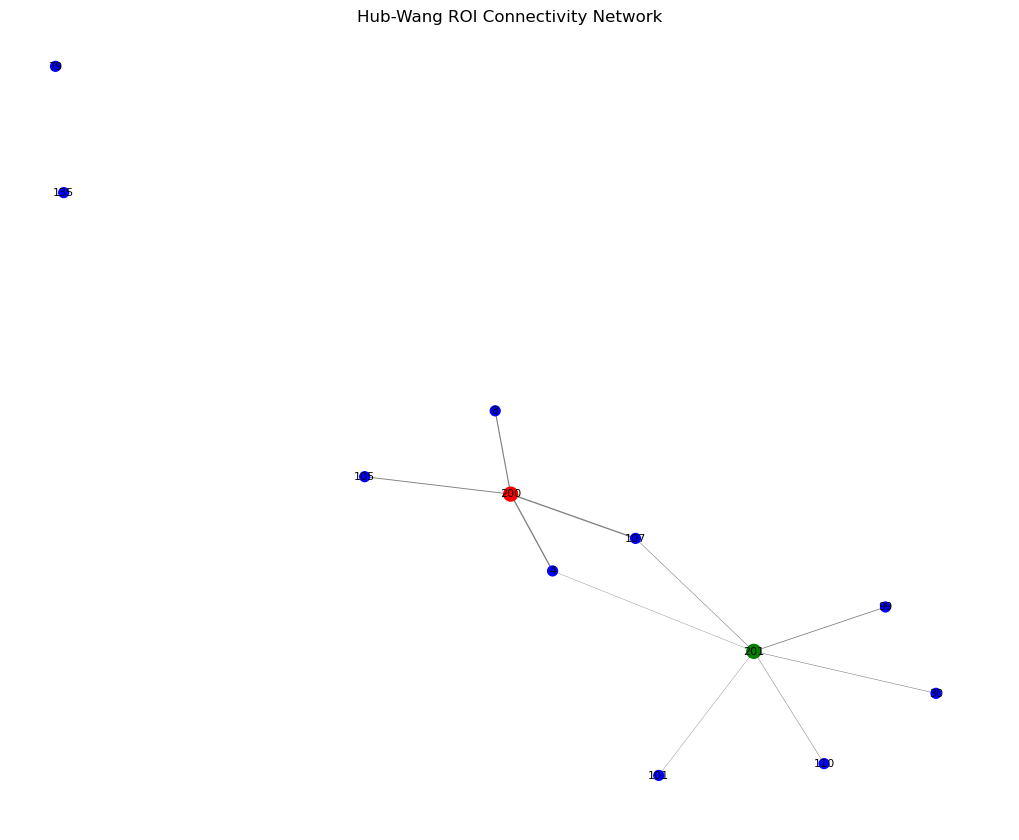

In [32]:
# 3. ROI validation with Wang atlas
def validate_wang_roi_connections(top_hubs, diff_matrices, atlas_labels, atlas_img):
    """Analyze connections between hubs and Wang ROIs (pIPS, LO)"""
    # Get average difference matrix
    avg_diff = np.mean([m for m in diff_matrices.values()], axis=0)
    
    # Find Wang ROI indices
    wang_rois = {'pIPS': 200, 'LO': 201}
    
    # Get top 10 hubs
    top_n = min(10, len(top_hubs))
    hub_rois = top_hubs.head(top_n)['ROI'].values.astype(int)
    
    # Calculate connections to Wang ROIs
    pips_conn = [avg_diff[hub, wang_rois['pIPS']] for hub in hub_rois]
    lo_conn = [avg_diff[hub, wang_rois['LO']] for hub in hub_rois]
    
    # Create first plot (bar chart only)
    plt.figure(figsize=(12, 6))
    x = np.arange(len(hub_rois))
    width = 0.35
    
    plt.bar(x - width/2, pips_conn, width, label='pIPS Connection')
    plt.bar(x + width/2, lo_conn, width, label='LO Connection')
    
    plt.xlabel('Hub ROI')
    plt.ylabel('Connection Strength')
    plt.title('Hub Connections to Wang ROIs')
    plt.xticks(x, [f"{roi}" for roi in hub_rois])
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Create second plot (brain connectivity)
    plt.figure(figsize=(10, 8))
    
    # Get coordinates
    coords = plotting.find_parcellation_cut_coords(atlas_img)
    
    # Create connectivity matrix for visualization
    n_nodes = len(atlas_labels)
    conn_matrix = np.zeros((n_nodes, n_nodes))
    
    # Add hub-to-Wang connections
    for hub in hub_rois:
        # Only add positive connections
        if avg_diff[hub, wang_rois['pIPS']] > 0:
            conn_matrix[hub, wang_rois['pIPS']] = avg_diff[hub, wang_rois['pIPS']]
            conn_matrix[wang_rois['pIPS'], hub] = avg_diff[hub, wang_rois['pIPS']]
        
        if avg_diff[hub, wang_rois['LO']] > 0:
            conn_matrix[hub, wang_rois['LO']] = avg_diff[hub, wang_rois['LO']]
            conn_matrix[wang_rois['LO'], hub] = avg_diff[hub, wang_rois['LO']]
    
    # Create node colors and sizes
    node_colors = ['gray'] * n_nodes
    node_sizes = [0] * n_nodes
    
    # Set colors for hubs and Wang ROIs
    for hub in hub_rois:
        node_colors[hub] = 'blue'
        node_sizes[hub] = 30
    
    node_colors[wang_rois['pIPS']] = 'red'
    node_colors[wang_rois['LO']] = 'green'
    node_sizes[wang_rois['pIPS']] = 100
    node_sizes[wang_rois['LO']] = 100
    
    # Try different display modes
    try:
        plotting.plot_connectome(
            conn_matrix, coords,
            node_color=node_colors,
            node_size=node_sizes,
            edge_threshold='5%',  # Keeping original threshold
            display_mode='ortho',  # Keeping original display mode
            edge_cmap='hot',
            colorbar=True,
            title='Hub-Wang ROI Connectivity'
        )
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error in connectivity plot: {e}")
    
    # Print summary
    print("\nWang ROI Connections:")
    print("------------------")
    print(f"pIPS (ROI {wang_rois['pIPS']}):")
    for i, hub in enumerate(hub_rois):
        if pips_conn[i] > 0:
            print(f"  Hub {hub}: {atlas_labels[hub]} (strength: {pips_conn[i]:.3f})")
    
    print(f"\nLO (ROI {wang_rois['LO']}):")
    for i, hub in enumerate(hub_rois):
        if lo_conn[i] > 0:
            print(f"  Hub {hub}: {atlas_labels[hub]} (strength: {lo_conn[i]:.3f})")

# Run Wang ROI validation
validate_wang_roi_connections(sig_hubs, diff_matrices, atlas_labels, atlas_img)

## OPTIONAL ##
# Alternative visualization approach
plt.figure(figsize=(10, 8))

# Create a simple network graph
G = nx.Graph()

# Add nodes
for hub in hub_rois:
    G.add_node(hub, color='blue', size=50)

G.add_node(wang_rois['pIPS'], color='red', size=100)
G.add_node(wang_rois['LO'], color='green', size=100)

# Add edges for strong connections
for hub in hub_rois:
    if avg_diff[hub, wang_rois['pIPS']] > 0.05:
        G.add_edge(hub, wang_rois['pIPS'], weight=avg_diff[hub, wang_rois['pIPS']]*5)
    
    if avg_diff[hub, wang_rois['LO']] > 0.05:
        G.add_edge(hub, wang_rois['LO'], weight=avg_diff[hub, wang_rois['LO']]*5)

# Extract node attributes
node_colors = [G.nodes[n]['color'] for n in G.nodes()]
node_sizes = [G.nodes[n]['size'] for n in G.nodes()]

# Set positions using spring layout
pos = nx.spring_layout(G, seed=42)

# Draw the graph
nx.draw(G, pos, 
        node_color=node_colors,
        node_size=node_sizes,
        with_labels=True,
        width=[G[u][v]['weight'] for u, v in G.edges()],
        edge_color='gray',
        font_size=8)

plt.title('Hub-Wang ROI Connectivity Network')
plt.tight_layout()
plt.show()

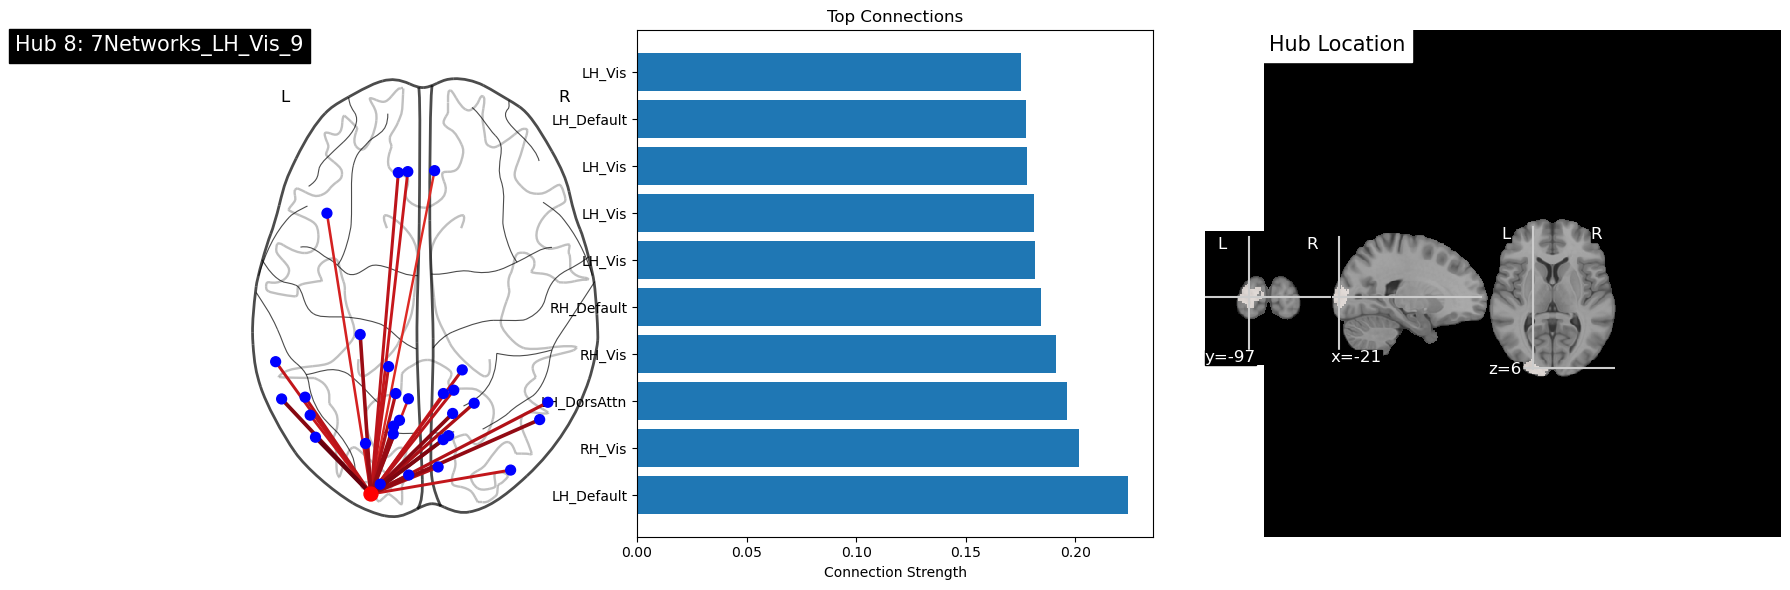


Hub 8 (7Networks_LH_Vis_9) significant connections:
1. 7Networks_LH_Vis_4 (strength = 0.182, t = 4.20)
2. 7Networks_LH_Vis_6 (strength = 0.129, t = 3.48)
3. 7Networks_LH_Vis_10 (strength = 0.178, t = 3.50)
4. 7Networks_LH_Vis_12 (strength = 0.113, t = 3.03)
5. 7Networks_LH_Vis_13 (strength = 0.181, t = 3.60)
6. 7Networks_LH_Vis_14 (strength = 0.175, t = 3.26)
7. 7Networks_LH_DorsAttn_Post_2 (strength = 0.196, t = 5.38)
8. 7Networks_LH_DorsAttn_Post_9 (strength = 0.096, t = 3.28)
9. 7Networks_LH_Limbic_OFC_2 (strength = 0.133, t = 4.88)
10. 7Networks_LH_Cont_Temp_1 (strength = 0.126, t = 4.16)


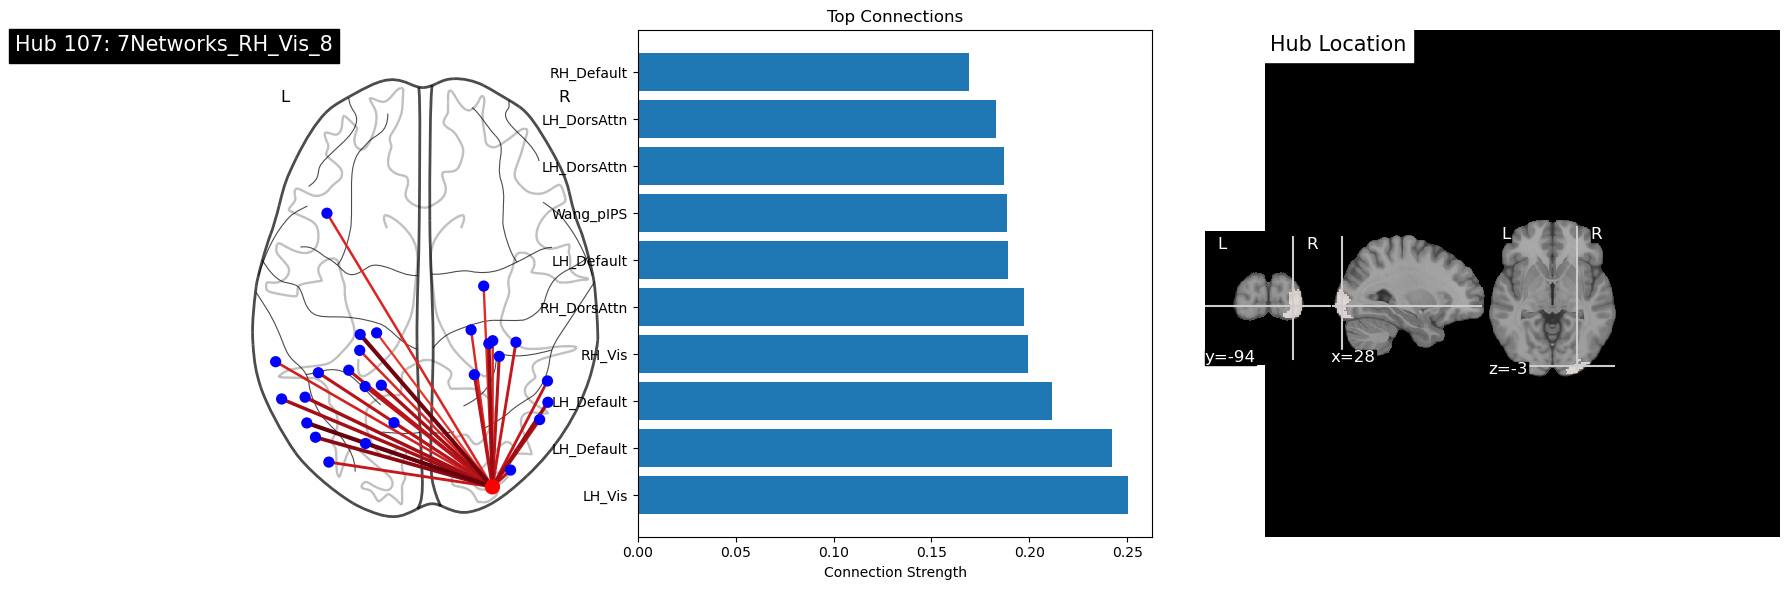


Hub 107 (7Networks_RH_Vis_8) significant connections:
1. 7Networks_LH_Vis_1 (strength = 0.152, t = 4.82)
2. 7Networks_LH_Vis_8 (strength = 0.250, t = 7.37)
3. 7Networks_LH_Vis_11 (strength = 0.131, t = 3.48)
4. 7Networks_LH_SomMot_11 (strength = 0.155, t = 4.58)
5. 7Networks_LH_SomMot_13 (strength = 0.100, t = 4.06)
6. 7Networks_LH_SomMot_16 (strength = 0.073, t = 3.89)
7. 7Networks_LH_DorsAttn_Post_1 (strength = 0.154, t = 5.01)
8. 7Networks_LH_DorsAttn_Post_2 (strength = 0.187, t = 7.06)
9. 7Networks_LH_DorsAttn_Post_7 (strength = 0.117, t = 3.54)
10. 7Networks_LH_DorsAttn_Post_10 (strength = 0.183, t = 5.75)


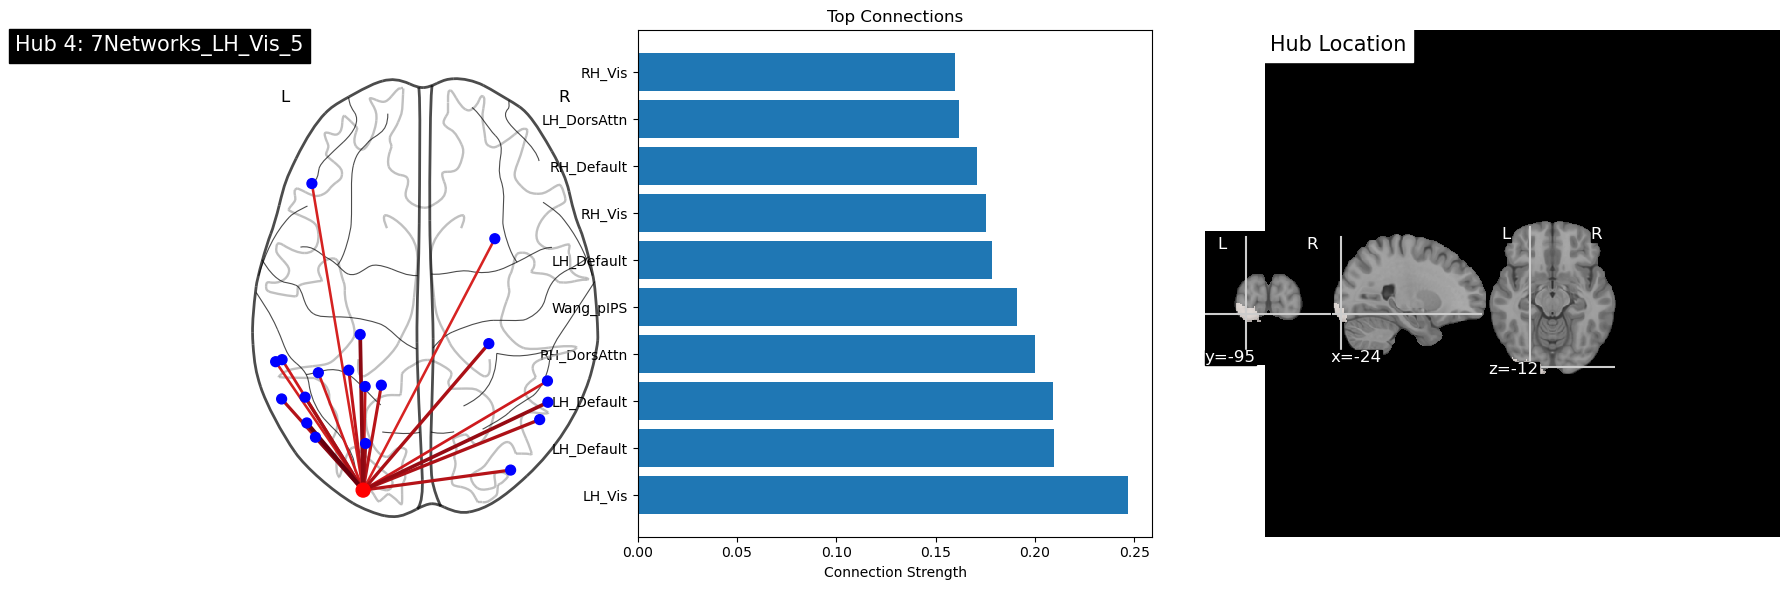


Hub 4 (7Networks_LH_Vis_5) significant connections:
1. 7Networks_LH_Vis_1 (strength = 0.141, t = 3.49)
2. 7Networks_LH_Vis_8 (strength = 0.247, t = 5.29)
3. 7Networks_LH_SomMot_11 (strength = 0.142, t = 3.77)
4. 7Networks_LH_DorsAttn_Post_1 (strength = 0.115, t = 3.61)
5. 7Networks_LH_DorsAttn_Post_2 (strength = 0.162, t = 3.60)
6. 7Networks_LH_DorsAttn_Post_10 (strength = 0.153, t = 3.58)
7. 7Networks_LH_Cont_Temp_1 (strength = 0.109, t = 3.37)
8. 7Networks_LH_Default_Temp_5 (strength = 0.120, t = 3.64)
9. 7Networks_LH_Default_Par_1 (strength = 0.178, t = 3.98)
10. 7Networks_LH_Default_Par_2 (strength = 0.209, t = 4.83)


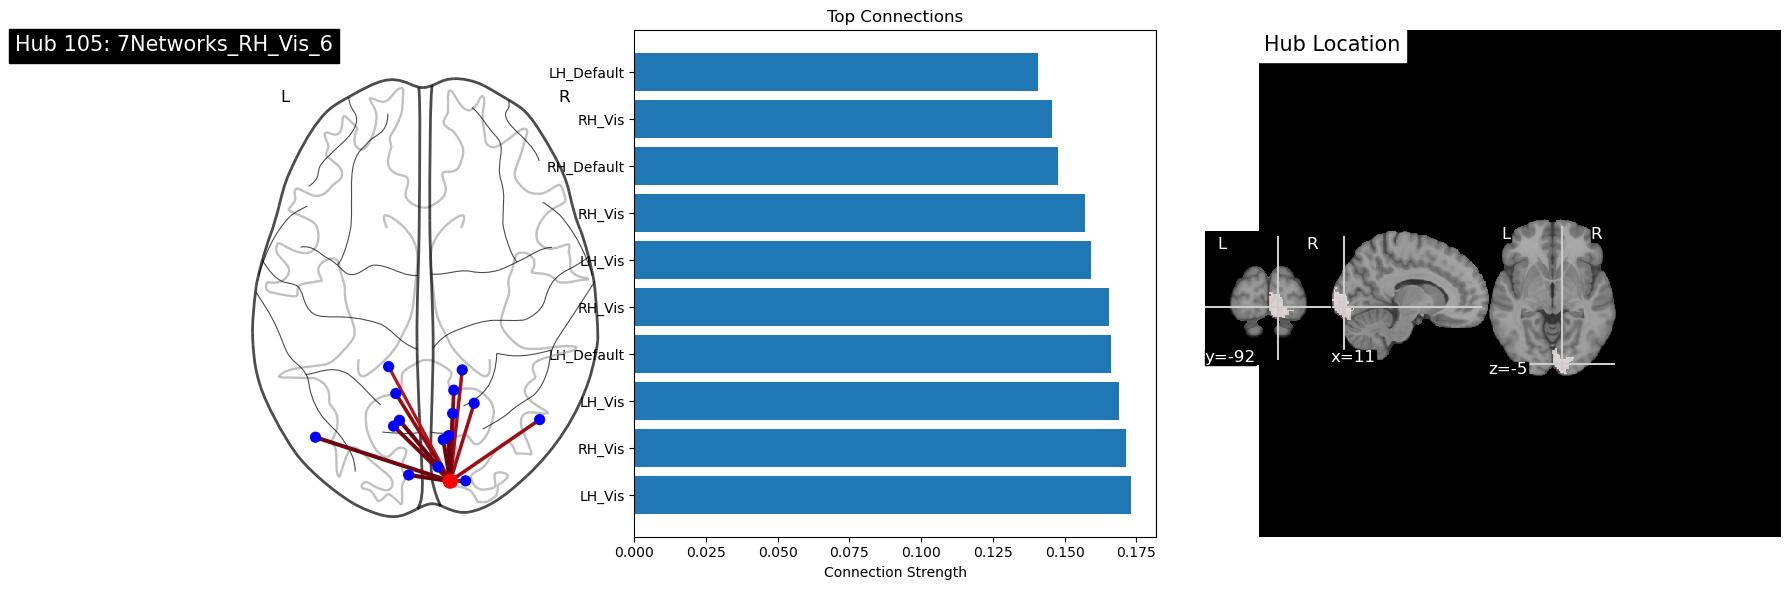


Hub 105 (7Networks_RH_Vis_6) significant connections:
1. 7Networks_LH_Vis_4 (strength = 0.169, t = 5.05)
2. 7Networks_LH_Vis_6 (strength = 0.109, t = 3.90)
3. 7Networks_LH_Vis_10 (strength = 0.159, t = 4.61)
4. 7Networks_LH_Vis_13 (strength = 0.173, t = 4.61)
5. 7Networks_LH_Default_Par_2 (strength = 0.166, t = 4.11)
6. 7Networks_LH_Default_pCunPCC_1 (strength = 0.141, t = 4.03)
7. 7Networks_RH_Vis_4 (strength = 0.157, t = 4.66)
8. 7Networks_RH_Vis_7 (strength = 0.128, t = 4.93)
9. 7Networks_RH_Vis_9 (strength = 0.166, t = 4.62)
10. 7Networks_RH_Vis_10 (strength = 0.131, t = 4.38)


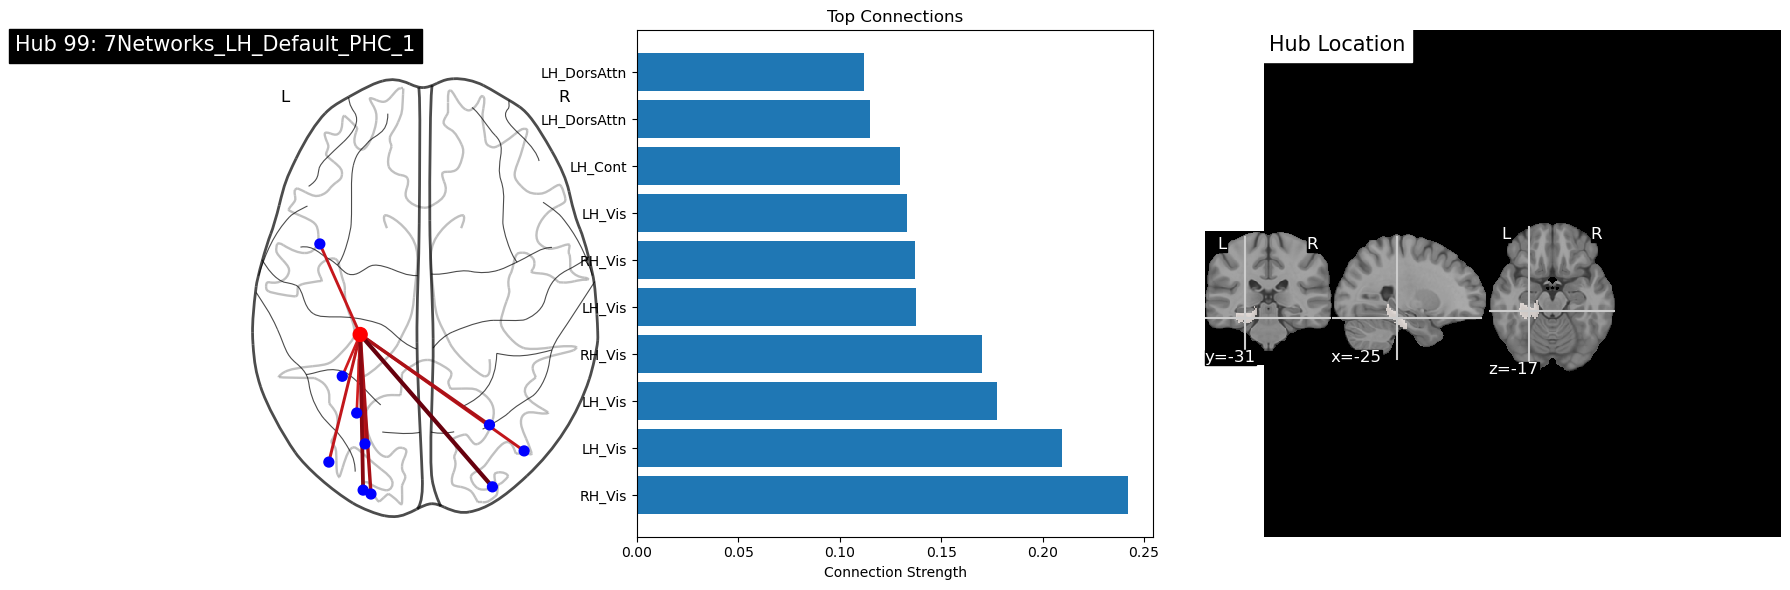


Hub 99 (7Networks_LH_Default_PHC_1) significant connections:
1. 7Networks_LH_Vis_2 (strength = 0.133, t = 5.51)
2. 7Networks_LH_Vis_5 (strength = 0.210, t = 5.03)
3. 7Networks_LH_Vis_9 (strength = 0.178, t = 5.04)
4. 7Networks_LH_Vis_11 (strength = 0.138, t = 4.54)
5. 7Networks_LH_DorsAttn_Post_3 (strength = 0.112, t = 5.03)
6. 7Networks_LH_DorsAttn_Post_6 (strength = 0.115, t = 3.47)
7. 7Networks_LH_Cont_PFCl_5 (strength = 0.130, t = 4.22)
8. 7Networks_RH_Vis_3 (strength = 0.170, t = 6.02)
9. 7Networks_RH_Vis_8 (strength = 0.242, t = 6.57)
10. 7Networks_RH_Vis_11 (strength = 0.137, t = 5.19)


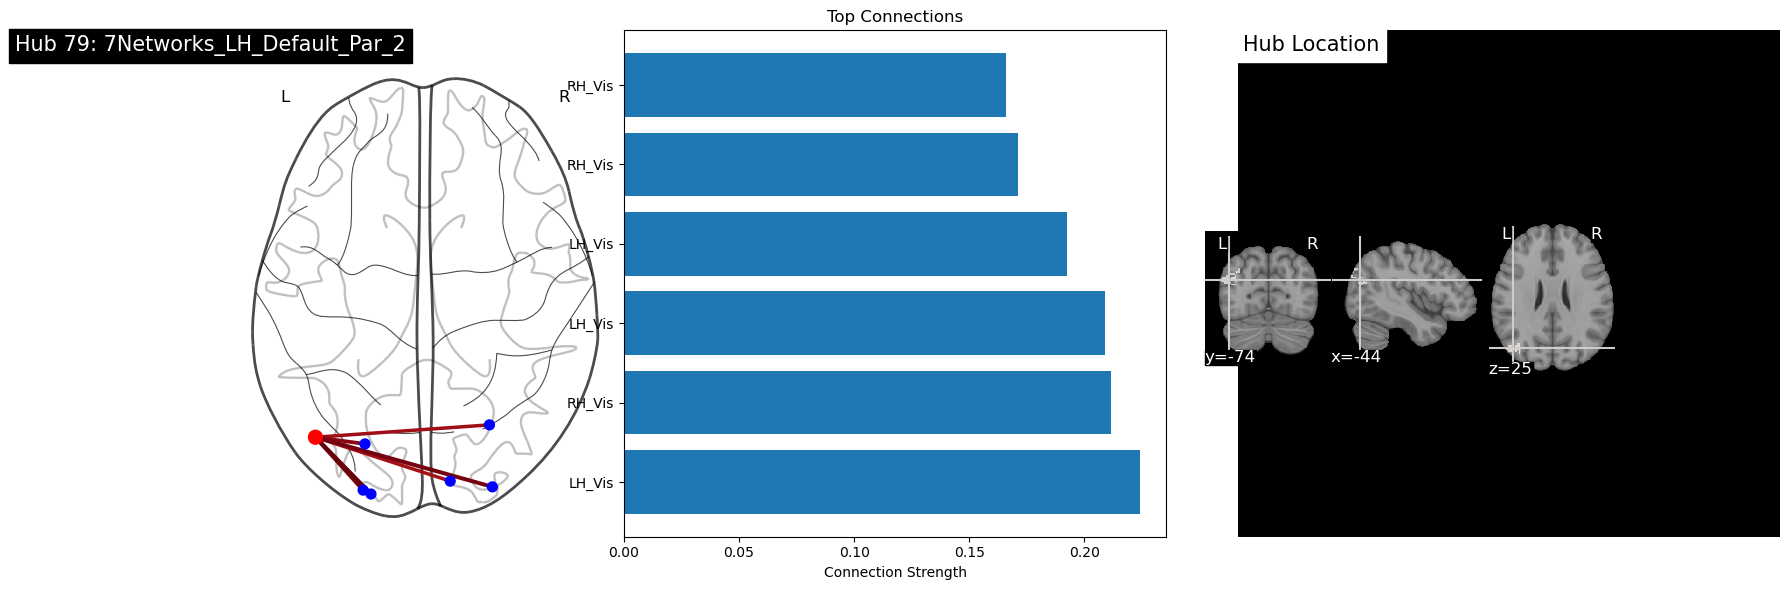


Hub 79 (7Networks_LH_Default_Par_2) significant connections:
1. 7Networks_LH_Vis_2 (strength = 0.192, t = 5.32)
2. 7Networks_LH_Vis_5 (strength = 0.209, t = 4.83)
3. 7Networks_LH_Vis_9 (strength = 0.224, t = 4.55)
4. 7Networks_RH_Vis_3 (strength = 0.171, t = 3.90)
5. 7Networks_RH_Vis_6 (strength = 0.166, t = 4.11)
6. 7Networks_RH_Vis_8 (strength = 0.212, t = 4.05)


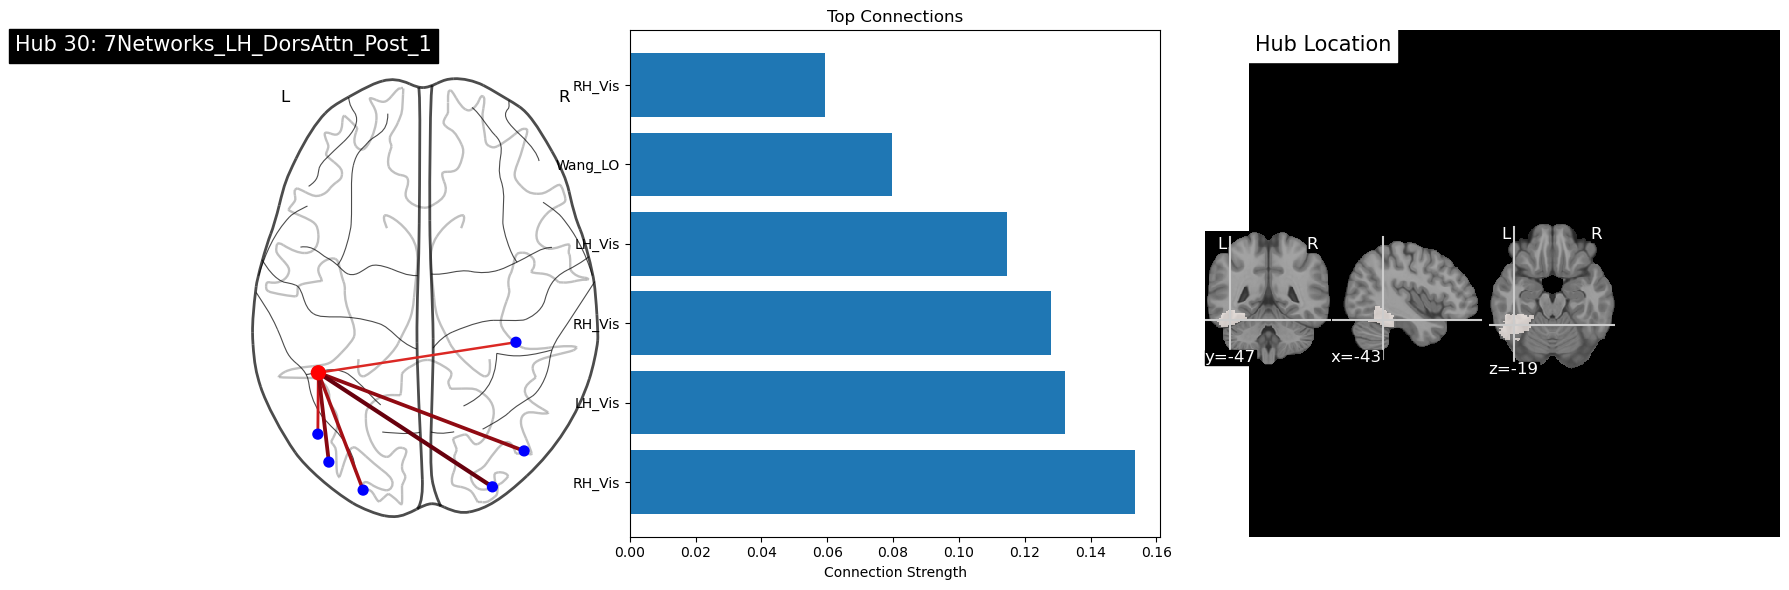


Hub 30 (7Networks_LH_DorsAttn_Post_1) significant connections:
1. 7Networks_LH_Vis_5 (strength = 0.115, t = 3.61)
2. 7Networks_LH_Vis_11 (strength = 0.132, t = 4.40)
3. 7Networks_RH_Vis_1 (strength = 0.059, t = 3.32)
4. 7Networks_RH_Vis_8 (strength = 0.154, t = 5.01)
5. 7Networks_RH_Vis_11 (strength = 0.128, t = 3.74)
6. Wang_LO (strength = 0.080, t = 3.34)


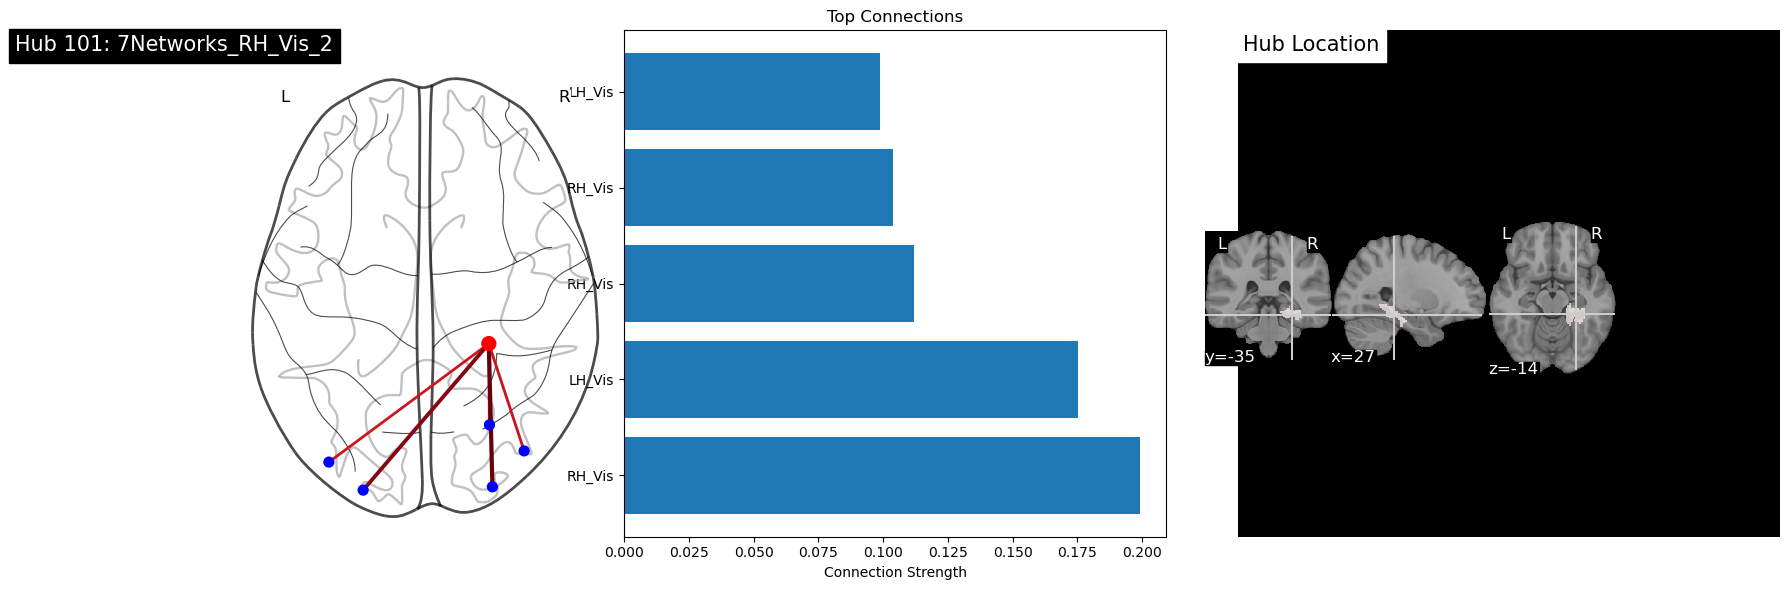


Hub 101 (7Networks_RH_Vis_2) significant connections:
1. 7Networks_LH_Vis_5 (strength = 0.175, t = 4.05)
2. 7Networks_LH_Vis_11 (strength = 0.099, t = 3.28)
3. 7Networks_RH_Vis_3 (strength = 0.112, t = 4.81)
4. 7Networks_RH_Vis_8 (strength = 0.199, t = 5.65)
5. 7Networks_RH_Vis_11 (strength = 0.104, t = 3.70)


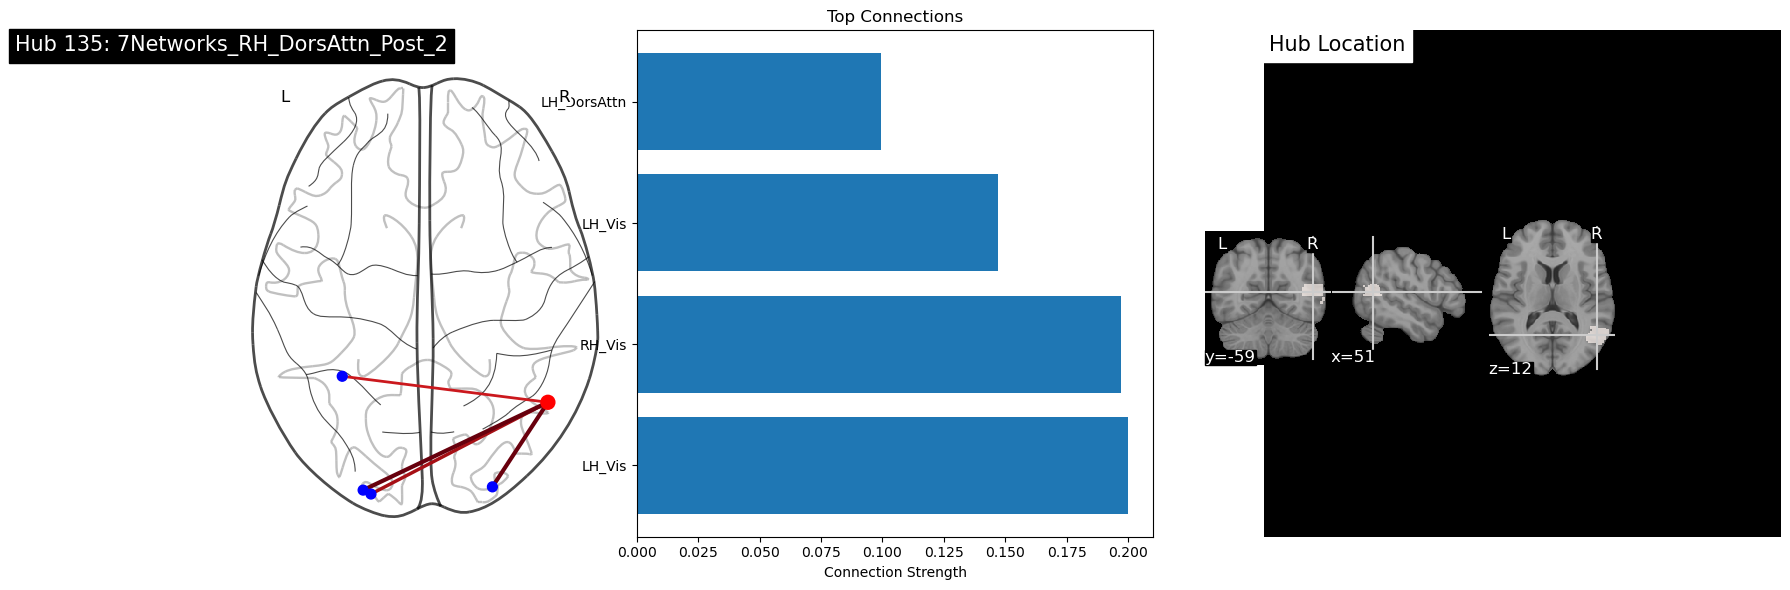


Hub 135 (7Networks_RH_DorsAttn_Post_2) significant connections:
1. 7Networks_LH_Vis_5 (strength = 0.200, t = 4.19)
2. 7Networks_LH_Vis_9 (strength = 0.147, t = 4.01)
3. 7Networks_LH_DorsAttn_Post_6 (strength = 0.099, t = 3.41)
4. 7Networks_RH_Vis_8 (strength = 0.197, t = 6.25)


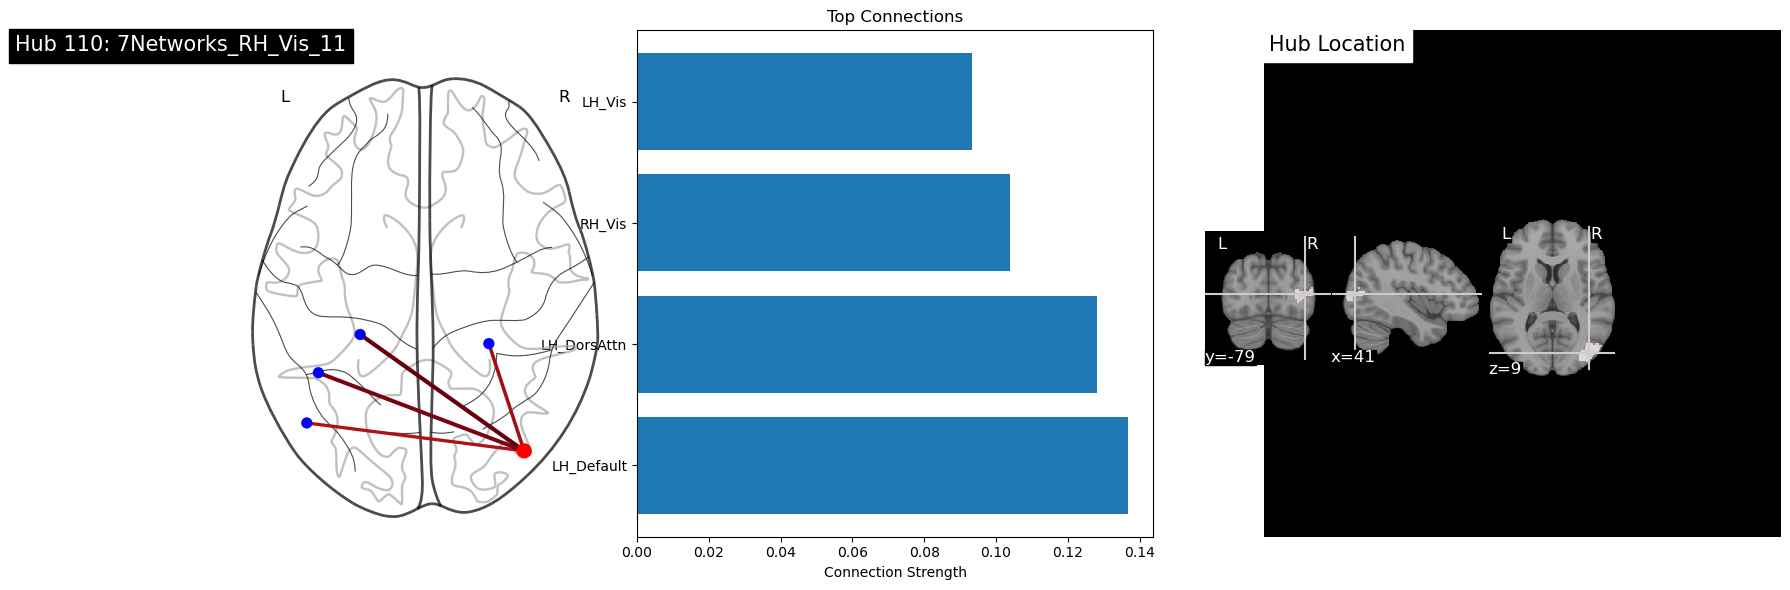


Hub 110 (7Networks_RH_Vis_11) significant connections:
1. 7Networks_LH_Vis_8 (strength = 0.093, t = 3.49)
2. 7Networks_LH_DorsAttn_Post_1 (strength = 0.128, t = 3.74)
3. 7Networks_LH_Default_PHC_1 (strength = 0.137, t = 5.19)
4. 7Networks_RH_Vis_2 (strength = 0.104, t = 3.70)


In [34]:
# 4. Advanced visualization of top hubs
from nilearn import image  # Add this import

def create_advanced_hub_visualizations(top_hubs, diff_matrices, atlas_img, atlas_labels):
    """Create detailed visualizations for top hub ROIs"""
    # Get average difference matrix
    avg_diff = np.mean([m for m in diff_matrices.values()], axis=0)
    
    # Get top 10 hubs instead of 5
    top_n = min(10, len(top_hubs))
    hub_rois = top_hubs.head(top_n)['ROI'].values.astype(int)
    
    # Get coordinates
    coords = plotting.find_parcellation_cut_coords(atlas_img)
    
    # Process each hub
    for hub_idx, hub_roi in enumerate(hub_rois):
        # Get connections for this hub
        from statsmodels.stats.multitest import fdrcorrection
        
        # Get t-statistics for connections
        roi_values = [diff[hub_roi, :] for diff in diff_matrices.values()]
        roi_values = np.array(roi_values)
        
        t_stats = []
        p_values = []
        
        for conn in range(avg_diff.shape[1]):
            if hub_roi != conn:  # Skip self-connections
                t, p = stats.ttest_1samp(roi_values[:, conn], 0)
                t_stats.append(t)
                p_values.append(p)
            else:
                t_stats.append(0)
                p_values.append(1.0)
        
        # Apply FDR correction
        significant, corrected_p = fdrcorrection(p_values, alpha=0.05)
        
        # Keep only significant positive connections
        pos_t = np.array(t_stats) > 0
        sig_pos = significant & pos_t
        
        # Create connection matrix for visualization
        conn_matrix = np.zeros((avg_diff.shape[0], avg_diff.shape[0]))
        
        sig_indices = np.where(sig_pos)[0]
        for idx in sig_indices:
            conn_matrix[hub_roi, idx] = avg_diff[hub_roi, idx]
            conn_matrix[idx, hub_roi] = avg_diff[hub_roi, idx]
        
        # Create plot for this hub
        plt.figure(figsize=(18, 6))
        
        # 1. Connectome plot
        plt.subplot(131)
        hub_name = atlas_labels[hub_roi] if hub_roi < len(atlas_labels) else f"ROI_{hub_roi}"
        
        # Create node colors (hub = red, connections = blue)
        node_colors = ['gray'] * len(coords)
        node_colors[hub_roi] = 'red'
        for idx in sig_indices:
            node_colors[idx] = 'blue'
        
        # Create node sizes
        node_sizes = [0] * len(coords)
        node_sizes[hub_roi] = 100
        for idx in sig_indices:
            node_sizes[idx] = 50
        
        # Plot connectome
        view_connectome = plotting.plot_connectome(
            conn_matrix, coords,
            node_color=node_colors,
            node_size=node_sizes,
            edge_threshold='0%',
            display_mode='z',
            axes=plt.gca(),
            edge_cmap='Reds',
            title=f'Hub {hub_roi}: {hub_name}'
        )
        
        # 2. Connection strength plot
        plt.subplot(132)
        if len(sig_indices) > 0:
            # Sort by strength
            conn_strengths = [avg_diff[hub_roi, idx] for idx in sig_indices]
            sorted_idx = np.argsort(conn_strengths)[::-1]
            
            top_connections = min(10, len(sig_indices))
            top_strengths = [conn_strengths[i] for i in sorted_idx[:top_connections]]
            top_rois = [sig_indices[i] for i in sorted_idx[:top_connections]]
            top_labels = [atlas_labels[i] if i < len(atlas_labels) else f"ROI_{i}" for i in top_rois]
            
            # Create abbreviated labels
            short_labels = []
            for label in top_labels:
                if isinstance(label, bytes):
                    label = label.decode('utf-8')
                parts = str(label).split('_')
                if len(parts) >= 3:
                    short_labels.append(f"{parts[1]}_{parts[2]}")
                else:
                    short_labels.append(str(label))
            
            # Plot
            plt.barh(range(len(top_strengths)), top_strengths)
            plt.yticks(range(len(top_strengths)), short_labels)
            plt.xlabel('Connection Strength')
            plt.title('Top Connections')
        else:
            plt.text(0.5, 0.5, "No significant connections", 
                   horizontalalignment='center', verticalalignment='center')
        
        # 3. Hub network position - Add a brain background
        plt.subplot(133)
        
        # Get ROI and highlight it
        roi_img = image.math_img('img == '+str(hub_roi+1), img=atlas_img)
        
        # Create display with a standard MNI template as background
        # Use a standard MNI template for the background
        from nilearn.datasets import load_mni152_template
        mni_template = load_mni152_template()
        
        plotting.plot_roi(roi_img, 
                        bg_img=mni_template,  # Add background brain image
                        cmap='Reds',
                        alpha=0.7,
                        draw_cross=True,  # Add crosshairs
                        axes=plt.gca(),
                        title=f'Hub Location')
        
        plt.tight_layout()
        plt.show()
        
        # Print connection information
        print(f"\nHub {hub_roi} ({hub_name}) significant connections:")
        for i, idx in enumerate(sig_indices[:10]):  # Show top 10 connections
            target_name = atlas_labels[idx] if idx < len(atlas_labels) else f"ROI_{idx}"
            print(f"{i+1}. {target_name} (strength = {avg_diff[hub_roi, idx]:.3f}, t = {t_stats[idx]:.2f})")

# Run advanced visualization
create_advanced_hub_visualizations(sig_hubs, diff_matrices, atlas_img, atlas_labels)

in the future don't bother with NetPlotBrain

<Figure size 800x600 with 0 Axes>

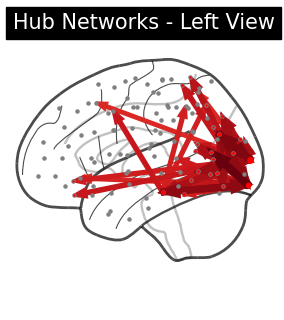

<Figure size 800x600 with 0 Axes>

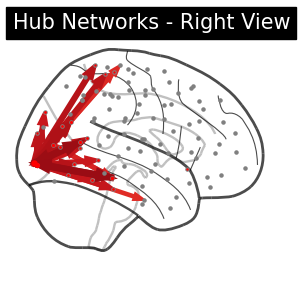

<Figure size 800x600 with 0 Axes>

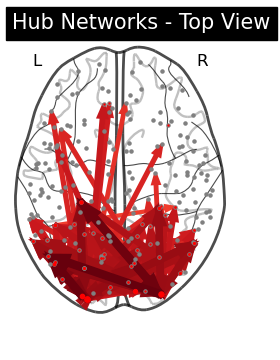

In [34]:
def visualize_hub_neighborhoods():
    # Get coordinates from atlas
    coords = plotting.find_parcellation_cut_coords(atlas_img)
    
    # Get top 10 hubs
    top_hubs = sig_hubs.head(10)
    top_hub_indices = [int(hub['ROI']) for _, hub in top_hubs.iterrows()]
    
    # Create a connection matrix focused on top hubs
    n_rois = len(coords)
    conn_matrix = np.zeros((n_rois, n_rois))
    
    # Get average difference matrix
    avg_diff = np.mean([m for m in diff_matrices.values()], axis=0)
    
    # For each top hub, find its significant connections
    for hub_roi in top_hub_indices:
        # Get t-statistics for connections
        roi_values = [diff[hub_roi, :] for diff in diff_matrices.values()]
        roi_values = np.array(roi_values)
        
        t_stats = []
        p_values = []
        for conn in range(len(coords)):
            if hub_roi != conn:  # Skip self-connections
                t, p = stats.ttest_1samp(roi_values[:, conn], 0)
                t_stats.append(t)
                p_values.append(p)
            else:
                t_stats.append(0)
                p_values.append(1.0)
        
        # Apply FDR correction
        significant, corrected_p = fdrcorrection(p_values, alpha=0.05)
        
        # Keep only significant positive connections
        pos_t = np.array(t_stats) > 0
        sig_pos = significant & pos_t
        
        # Add to connection matrix
        sig_indices = np.where(sig_pos)[0]
        for idx in sig_indices:
            conn_matrix[hub_roi, idx] = avg_diff[hub_roi, idx]
    
    # Use valid display modes
    views = ['l', 'r', 'z']  # Left, Right, Top
    view_names = ['Left', 'Right', 'Top']
    
    # Plot each view separately for clarity
    for view, name in zip(views, view_names):
        plt.figure(figsize=(8, 6))
        display = plotting.plot_connectome(
            conn_matrix, coords, 
            node_color="gray",
            node_size=5,
            edge_cmap='Reds',
            display_mode=view,
            title=f'Hub Networks - {name} View'
        )
        
        # Highlight significant hubs
        for _, hub in sig_hubs.iterrows():
            roi = int(hub['ROI'])
            if roi < len(coords):
                # Size based on hub score
                marker_size = hub['Hub_Score'] * 100
                display.add_markers(
                    [coords[roi]], 
                    marker_color='red', 
                    marker_size=marker_size
                )
        
        plt.tight_layout()
        plt.show()

# Run visualization
visualize_hub_neighborhoods()

<Figure size 1500x500 with 0 Axes>

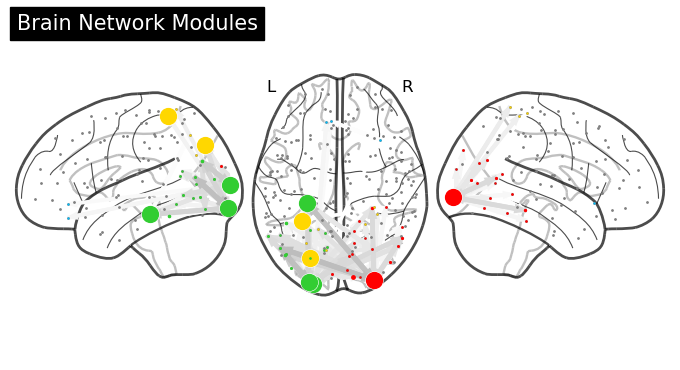

In [36]:
def visualize_hub_modules():
    # Get coordinates
    coords = plotting.find_parcellation_cut_coords(atlas_img)
    
    # Get significant hub indices
    hub_indices = [int(hub['ROI']) for _, hub in sig_hubs.iterrows()]
    
    # Extract coordinates for significant hubs only
    hub_coords = []
    roi_to_idx = {}  # Maps ROI numbers to indices in hub arrays
    
    for i, roi in enumerate(hub_indices):
        if roi < len(coords):
            hub_coords.append(coords[roi])
            roi_to_idx[roi] = i
    
    # Group hubs into modules (3-4 modules)
    from sklearn.cluster import AgglomerativeClustering
    
    n_clusters = min(4, len(hub_coords))
    if len(hub_coords) >= n_clusters:
        clustering = AgglomerativeClustering(n_clusters=n_clusters)
        clusters = clustering.fit_predict(hub_coords)
    else:
        clusters = np.zeros(len(hub_coords))
    
    # Create connection matrix
    n_rois = len(coords)
    conn_matrix = np.zeros((n_rois, n_rois))
    
    # Identify connector hubs (hubs with connections to multiple modules)
    avg_diff = np.mean([m for m in diff_matrices.values()], axis=0)
    
    # For each hub, add significant connections
    module_connections = {i: set() for i in range(n_clusters)}
    connector_hubs = set()
    
    for i, src_roi in enumerate(hub_indices):
        if src_roi >= len(coords) or i >= len(clusters):
            continue
            
        src_cluster = clusters[i]
        connected_modules = set()
        
        # Get t-statistics for connections
        roi_values = [diff[src_roi, :] for diff in diff_matrices.values()]
        roi_values = np.array(roi_values)
        
        # Find significant connections
        t_stats = []
        p_values = []
        for conn in range(n_rois):
            if src_roi != conn:
                t, p = stats.ttest_1samp(roi_values[:, conn], 0)
                t_stats.append(t)
                p_values.append(p)
            else:
                t_stats.append(0)
                p_values.append(1.0)
        
        # Apply FDR correction
        significant, corrected_p = fdrcorrection(p_values, alpha=0.05)
        
        # Keep only significant positive connections
        pos_t = np.array(t_stats) > 0
        sig_pos = significant & pos_t
        
        # Add connections to other hubs
        for j, tgt_roi in enumerate(hub_indices):
            if tgt_roi >= len(coords) or j >= len(clusters) or src_roi == tgt_roi:
                continue
                
            tgt_cluster = clusters[j]
            
            if sig_pos[tgt_roi]:
                # Add connection to matrix
                conn_value = avg_diff[src_roi, tgt_roi]
                conn_matrix[src_roi, tgt_roi] = conn_value
                
                # Track connection between modules
                if src_cluster != tgt_cluster:
                    connected_modules.add(tgt_cluster)
                    module_connections[src_cluster].add(tgt_cluster)
        
        # If hub connects to multiple other modules, mark as connector hub
        if len(connected_modules) > 1:
            connector_hubs.add(src_roi)
    
    # Create view with modules and connector hubs
    module_colors = ['red', 'gold', 'limegreen', 'deepskyblue']
    
    # Plot combined view
    plt.figure(figsize=(15, 5))
    display = plotting.plot_connectome(
        conn_matrix, coords, 
        node_color="gray",
        node_size=1,
        edge_cmap='Greys',
        edge_vmin=0.1, edge_vmax=0.5,
        display_mode='lzr',
        title='Brain Network Modules'
    )
    
    # Add module labels
    module_centers = [np.mean([hub_coords[i] for i, c in enumerate(clusters) if c == module], axis=0) 
                     for module in range(n_clusters)]
    
    # Add hubs by module
    for i, roi in enumerate(hub_indices):
        if roi >= len(coords) or i >= len(clusters):
            continue
            
        module = clusters[i]
        color = module_colors[module % len(module_colors)]
        
        # Use larger markers for connector hubs
        if roi in connector_hubs:
            marker_size = 150
            marker_color = 'white'  # Connector hubs in white
            display.add_markers([coords[roi]], marker_color=marker_color, marker_size=marker_size)
            # Add colored border by overlaying smaller marker
            display.add_markers([coords[roi]], marker_color=color, marker_size=marker_size-20)
        else:
            # Regular module hubs
            marker_size = sig_hubs.iloc[i]['Hub_Score'] * 80
            display.add_markers([coords[roi]], marker_color=color, marker_size=marker_size)
    
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_hub_modules()

<Figure size 1500x500 with 0 Axes>

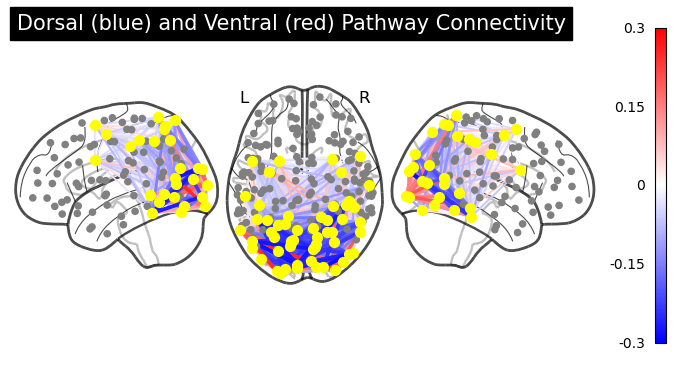

In [38]:
# Create a glass brain plot showing dorsal and ventral pathways separately
atlas_img, atlas_labels = load_merged_atlas()
coords = plotting.find_parcellation_cut_coords(atlas_img)

# Identify dorsal and ventral nodes
dorsal_nodes = [i for i, label in enumerate(atlas_labels) if 'DorsAttn' in label]
ventral_nodes = [i for i, label in enumerate(atlas_labels) if 'Vis' in label]

# Create a matrix highlighting between-pathway connections
pathway_matrix = np.zeros_like(avg_diff)
pathway_matrix[np.ix_(dorsal_nodes, dorsal_nodes)] = avg_diff[np.ix_(dorsal_nodes, dorsal_nodes)]
pathway_matrix[np.ix_(ventral_nodes, ventral_nodes)] = avg_diff[np.ix_(ventral_nodes, ventral_nodes)]
pathway_matrix[np.ix_(dorsal_nodes, ventral_nodes)] = avg_diff[np.ix_(dorsal_nodes, ventral_nodes)]
pathway_matrix[np.ix_(ventral_nodes, dorsal_nodes)] = avg_diff[np.ix_(ventral_nodes, dorsal_nodes)]

# Plot
plt.figure(figsize=(15, 5))
display = plotting.plot_connectome(
    pathway_matrix, coords,
    node_color=['blue' if i in dorsal_nodes else 'red' if i in ventral_nodes else 'gray' 
               for i in range(len(coords))],
    node_size=20,
    edge_cmap='bwr',
    edge_vmin=-0.3,
    edge_vmax=0.3,
    colorbar=True,
    display_mode='lzr',
    title='Dorsal (blue) and Ventral (red) Pathway Connectivity'
)

# Highlight significant hubs
hub_coords = [coords[hub] for hub in significant_hubs.keys() if hub in dorsal_nodes + ventral_nodes]
display.add_markers(hub_coords, marker_color='yellow', marker_size=50)

Text(2, -0.01544046938419342, '-0.025')

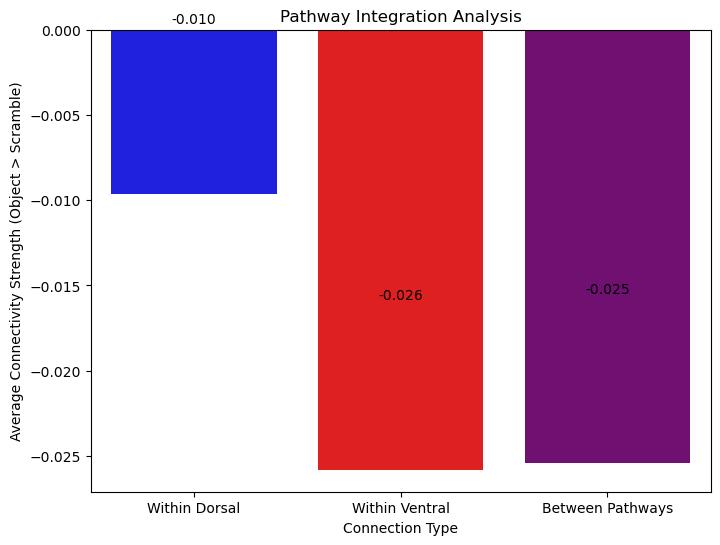

In [39]:
# Calculate and plot within/between pathway connectivity
dorsal_indices = [i for i, label in enumerate(atlas_labels) if 'DorsAttn' in label]
ventral_indices = [i for i, label in enumerate(atlas_labels) if 'Vis' in label]

# Calculate average connectivity strengths
within_dorsal = avg_diff[np.ix_(dorsal_indices, dorsal_indices)].mean()
within_ventral = avg_diff[np.ix_(ventral_indices, ventral_indices)].mean()
between = avg_diff[np.ix_(dorsal_indices, ventral_indices)].mean()

# Create dataframe for plotting
df = pd.DataFrame({
    'Connection Type': ['Within Dorsal', 'Within Ventral', 'Between Pathways'],
    'Strength': [within_dorsal, within_ventral, between]
})

# Plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=df, x='Connection Type', y='Strength', palette=['blue', 'red', 'purple'])
ax.set_title('Pathway Integration Analysis')
ax.set_ylabel('Average Connectivity Strength (Object > Scramble)')

# Add significance markers if you have stats
ax.text(0, within_dorsal+0.01, f'{within_dorsal:.3f}', ha='center')
ax.text(1, within_ventral+0.01, f'{within_ventral:.3f}', ha='center')
ax.text(2, between+0.01, f'{between:.3f}', ha='center')

(-1.2099999998334685,
 1.2099999982474536,
 -1.2098536619962463,
 1.2098536665502246)

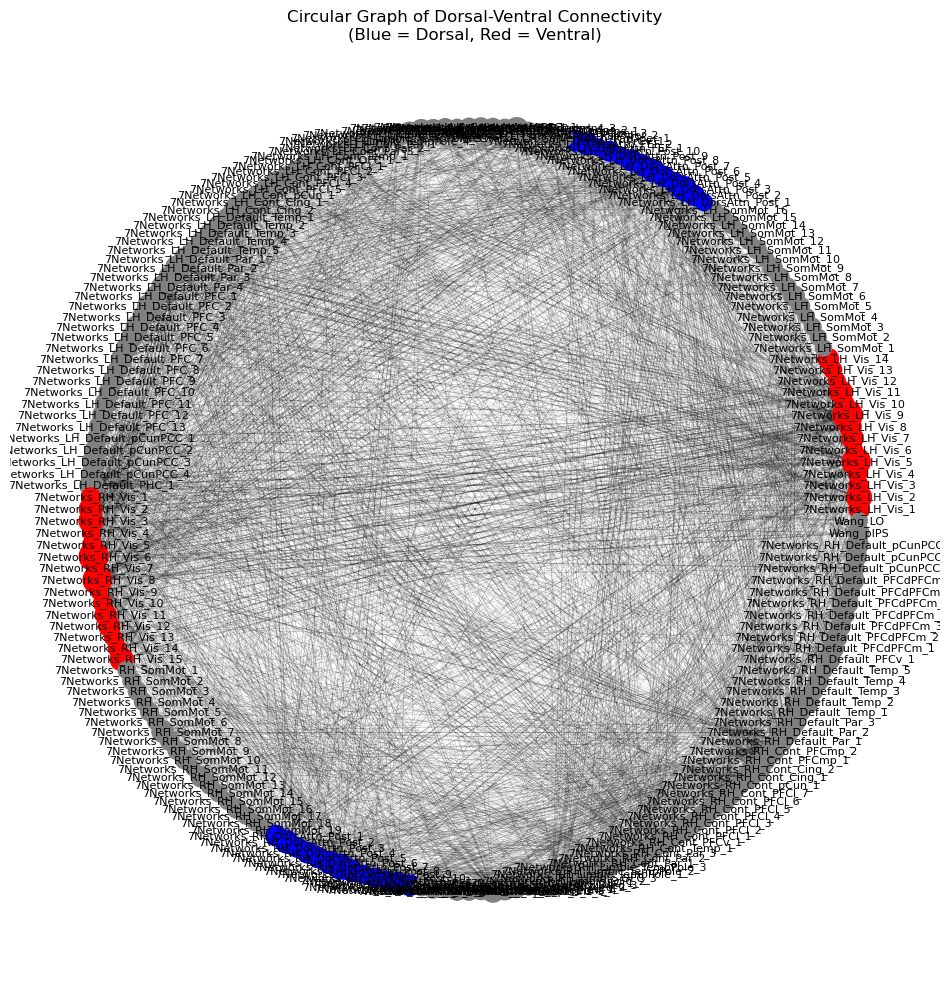

In [40]:
# Create a thresholded graph for visualization
threshold = np.mean(avg_diff) + np.std(avg_diff)
graph_matrix = avg_diff.copy()
graph_matrix[graph_matrix < threshold] = 0

# Create networkx graph
G = nx.from_numpy_array(graph_matrix)

# Classify nodes by pathway
node_colors = []
node_sizes = []
for node in G.nodes():
    if node in dorsal_indices:
        node_colors.append('blue')
    elif node in ventral_indices:
        node_colors.append('red')
    else:
        node_colors.append('gray')
    
    # Size by hub score if available
    if node in significant_hubs:
        node_sizes.append(significant_hubs[node]['mean_score'] * 3000)
    else:
        node_sizes.append(300)

# Get edge weights
edge_weights = [d['weight']*5 for u,v,d in G.edges(data=True)]

# Plot circular layout
plt.figure(figsize=(12, 12))
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color='black', alpha=0.3)

# Add labels for hubs
hub_labels = {node: atlas_labels[node] for node in G.nodes() if node in significant_hubs}
nx.draw_networkx_labels(G, pos, labels=hub_labels, font_size=8)

plt.title('Circular Graph of Dorsal-Ventral Connectivity\n(Blue = Dorsal, Red = Ventral)')
plt.axis('off')

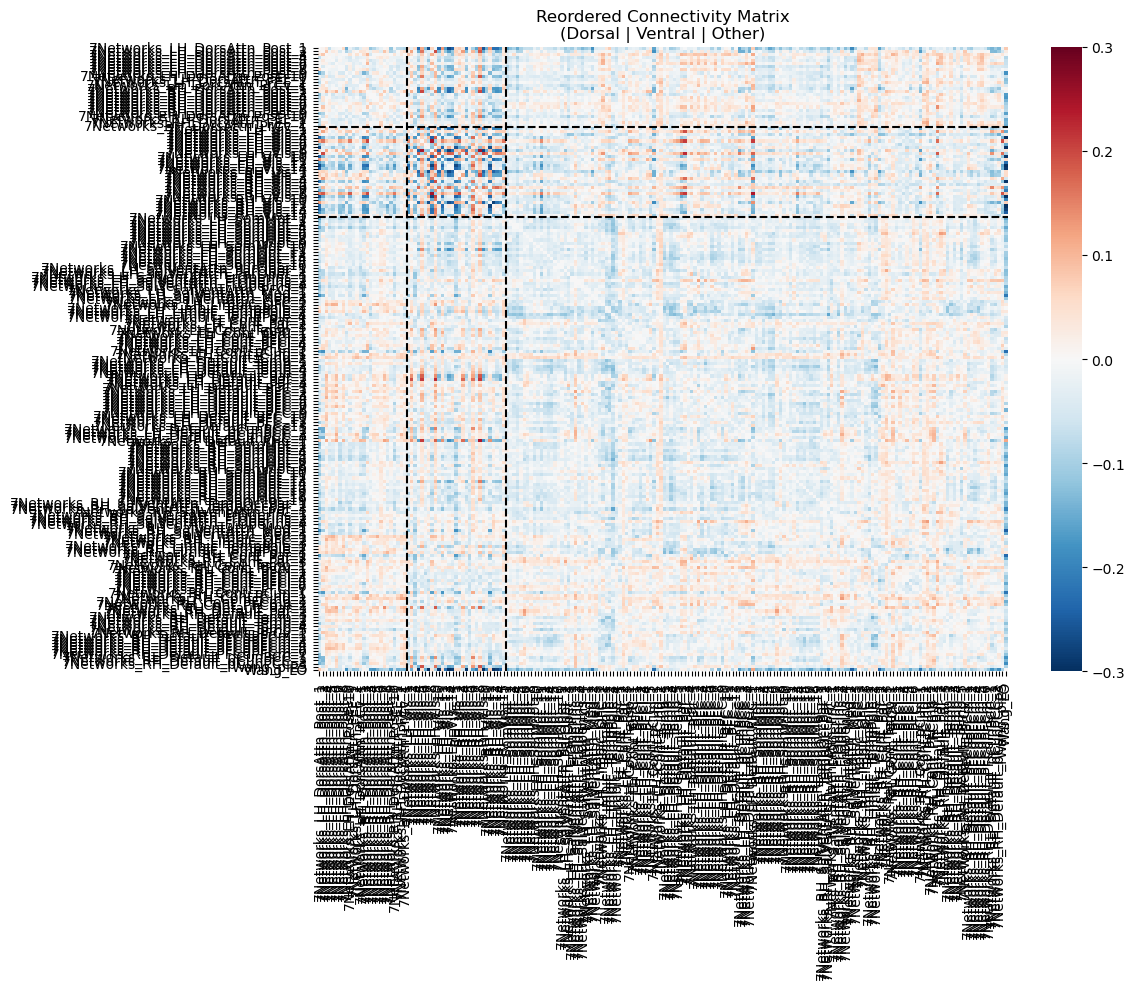

In [41]:
# Create a reordered matrix with dorsal and ventral regions grouped
all_nodes = dorsal_indices + ventral_indices + [i for i in range(len(atlas_labels)) 
              if i not in dorsal_indices and i not in ventral_indices]
ordered_labels = [atlas_labels[i] for i in all_nodes]

# Reorder matrix
reordered_matrix = avg_diff[np.ix_(all_nodes, all_nodes)]

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(reordered_matrix, 
            cmap='RdBu_r',
            center=0,
            xticklabels=ordered_labels,
            yticklabels=ordered_labels,
            vmin=-0.3,
            vmax=0.3)

# Add dividing lines
plt.axvline(x=len(dorsal_indices), color='black', linestyle='--')
plt.axhline(y=len(dorsal_indices), color='black', linestyle='--')
plt.axvline(x=len(dorsal_indices)+len(ventral_indices), color='black', linestyle='--')
plt.axhline(y=len(dorsal_indices)+len(ventral_indices), color='black', linestyle='--')

plt.title('Reordered Connectivity Matrix\n(Dorsal | Ventral | Other)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

# Defined using Schaefer Networks

#### Sub heading

In [44]:
# Define your custom dorsal/ventral indices (replace with your ROI classifications!)
dorsal_indices = [i for i, label in enumerate(atlas_labels) if 'DorsAttn' in label]  # Example: Schaefer dorsal attention
ventral_indices = [i for i, label in enumerate(atlas_labels) if 'Vis' in label]      # Example: Schaefer visual

# Calculate connectivity ratios for OBJECT > SCRAMBLE (avg_diff)
within_dorsal = avg_diff[np.ix_(dorsal_indices, dorsal_indices)].mean()
within_ventral = avg_diff[np.ix_(ventral_indices, ventral_indices)].mean()
between_dv = avg_diff[np.ix_(dorsal_indices, ventral_indices)].mean()

# Print results
print("OBJECT > SCRAMBLE CONNECTIVITY RATIOS:")
print(f"  Within Dorsal: {within_dorsal:.4f}")
print(f"  Within Ventral: {within_ventral:.4f}")
print(f"  Between Dorsal-Ventral: {between_dv:.4f}")
print(f"  Dorsal-Ventral Integration Ratio (Between/Within): {between_dv / ((within_dorsal + within_ventral)/2):.4f}")

OBJECT > SCRAMBLE CONNECTIVITY RATIOS:
  Within Dorsal: -0.0096
  Within Ventral: -0.0258
  Between Dorsal-Ventral: -0.0254
  Dorsal-Ventral Integration Ratio (Between/Within): 1.4366


Key Result
>Integration Ratio (Between/Within-Pathway) = 1.44
>This means:
> * Between-pathway connectivity (dorsal-ventral) is 44% stronger than the average within-pathway connectivity (dorsal-dorsal or ventral-ventral)
> * Interpretation: The dorsal and ventral streams are more interconnected than they are connected to themselves during object processing.

In [45]:
# Load scramble matrices (from your original code)
scramble_matrices = load_subject_matrices(results_dir, 'scramble')
avg_scramble = np.mean([m for m in scramble_matrices.values()], axis=0)

# Calculate scramble connectivity ratios
within_dorsal_scramble = avg_scramble[np.ix_(dorsal_indices, dorsal_indices)].mean()
within_ventral_scramble = avg_scramble[np.ix_(ventral_indices, ventral_indices)].mean()
between_dv_scramble = avg_scramble[np.ix_(dorsal_indices, ventral_indices)].mean()

# Compare object vs. scramble
print("\nSCRAMBLE-ONLY CONNECTIVITY RATIOS:")
print(f"  Within Dorsal: {within_dorsal_scramble:.4f}")
print(f"  Within Ventral: {within_ventral_scramble:.4f}")
print(f"  Between Dorsal-Ventral: {between_dv_scramble:.4f}")

print("\nOBJECT-SPECIFIC EFFECTS (Object - Scramble):")
print(f"  Within Dorsal Δ: {within_dorsal - within_dorsal_scramble:.4f}")
print(f"  Within Ventral Δ: {within_ventral - within_ventral_scramble:.4f}")
print(f"  Between Dorsal-Ventral Δ: {between_dv - between_dv_scramble:.4f}")

Found 18 scramble connectivity matrices

SCRAMBLE-ONLY CONNECTIVITY RATIOS:
  Within Dorsal: 0.5062
  Within Ventral: 0.4158
  Between Dorsal-Ventral: 0.3485

OBJECT-SPECIFIC EFFECTS (Object - Scramble):
  Within Dorsal Δ: -0.5158
  Within Ventral Δ: -0.4416
  Between Dorsal-Ventral Δ: -0.3739


In [46]:
# Perform paired t-tests across subjects for between-pathway connections
subjects = list(diff_matrices.keys())
between_dv_object = [np.mean(diff_matrices[sub][np.ix_(dorsal_indices, ventral_indices)]) for sub in subjects]
between_dv_scramble = [np.mean(scramble_matrices[sub][np.ix_(dorsal_indices, ventral_indices)]) for sub in subjects]

t_stat, p_val = stats.ttest_rel(between_dv_object, between_dv_scramble)
print(f"\nBetween-Pathway Connectivity (Object vs. Scramble):")
print(f"  t = {t_stat:.3f}, p = {p_val:.5f}")


Between-Pathway Connectivity (Object vs. Scramble):
  t = -11.450, p = 0.00000
